# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
from scipy import stats
import seaborn as sns

# Загрузка данных

In [2]:
df_train = pd.read_csv("../data/train.csv")
df_train.sort_index(inplace=True)
df_train.head(5)

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,...,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.466255,13.765101,15.337527,10.385377,7.640209,9.564493,7.787893,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,286.225,315.219829,126,0,0.160487,-0.492870,0.492870,0.160487,1.173913,1.956522,2.608696,16.507764,9.486685,2.502184,-2.562182,2.584438,-2.491154,5.425001,-0.007335,2.579710,1.480238,591.304512,16.449383,14.816132,14.816132,11.057210,8.664686,8.664686,7.437432,...,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,439.375,427.279,439.056210,156,0,0.436923,-0.274885,0.436923,0.274885,1.033333,1.633333,2.133333,32.227747,10.102030,2.384677,-2.040425,2.409619,-2.051216,7.903047,-0.384432,3.101827,2.026965,1217.774715,22.104084,15.082791,15.899288,13.964364,8.088569,9.979981,6.063630,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,134.117,151.136100,62,0,0.016184,-0.325030,0.325030,0.016184,0.818182,1.181818,1.454545,14.788664,9.531931,2.481276,-2.547053,2.539193,-2.552993,5.038957,0.000365,1.787472,1.940004,150.027586,7.474691,7.052042,7.052042,5.234895,5.023570,5.023570,5.279928,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
df_test = pd.read_csv("../data/test.csv")
df_test.sort_index(inplace=True)
df_test.head(5)

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,...,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,156,0,0.307795,-0.480983,0.480983,0.307795,1.129032,1.967742,2.741935,32.166547,9.704289,2.608086,-2.425359,2.544663,-2.545620,8.056645,-0.147725,3.494848,1.531269,1171.998965,21.275292,16.250243,17.883236,15.058551,10.093357,11.852663,8.159777,10.171294,6.660754,8.495535,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,0,0.238633,-0.507966,0.507966,0.238633,0.906250,1.593750,2.250000,16.707906,9.991346,2.450224,-2.390353,2.369524,-2.597794,5.878314,-0.277225,2.752143,1.885708,1185.055548,23.153972,16.321448,16.321448,15.205616,9.502898,9.502898,7.289468,7.289468,5.129606,5.129606,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,0,0.006729,-0.327440,0.327440,0.006729,1.000000,1.384615,1.692308,14.717158,9.477838,2.516654,-2.580818,2.603245,-2.529164,5.037930,-0.063729,2.001545,1.911265,183.880154,9.052042,8.629392,8.629392,6.178270,5.934254,5.934254,6.068603,6.068603,5.051530,5.051530,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,152,0,0.459915,-0.298106,0.459915,0.298106,1.035714,1.642857,2.214286,19.431747,9.748466,2.770160,-2.378300,2.497185,-2.609063,6.137362,-0.343838,3.093791,2.061305,820.544843,20.905413,14.019447,14.019447,12.892865,8.156244,8.156244,6.497592,6.497592,4.836450,4.836450,...,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,104,0,0.347113,-0.440980,0.440980,0.347113,0.904762,1.619048,2.428571,16.731298,9.952325,2.584407,-2.201773,2.471778,-2.366688,6.116909,-0.097822,2.896060,1.940561,821.534975,14.775656,11.597095,11.597095,10.026511,6.706796,6.706796,5.415498,5.415498,4.131136,4.131136,...,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Удалим ненужный признак Index

In [4]:
df_train = df_train.drop(columns="index")
df_test = df_test.drop(columns="index")

## Анализ данных

### Первичный осмотр

In [5]:
df_train.shape

(751, 213)

In [6]:
df_test.shape

(250, 210)

Обучающий датасет представлен 751 строкой и 213 признаками. Тестовый датасет представлен 250 строками, 210 признаками. 3 дополнительных признака в обучающем набором данных обусловлены наличием трех целевых переменных. Соотношение строк train/test составляет примерно 3:1.





In [7]:
df_train.dtypes.value_counts()

,count
float64,107
int64,106


In [8]:
df_test.dtypes.value_counts()

,count
int64,106
float64,104


Датасеты полностью состоят из числовых данных, что упрощает их использование для большинства моделей машинного обучения без необходимости дополнительного кодирования категориальных переменных.

### Анализ пропусков

In [9]:
df_train.isna().sum().sum()

np.int64(24)

In [10]:
for col in df_train.columns[df_train.isna().any()]:
    missing_rows = df_train[df_train[col].isna()].index.tolist()
    print(f"Колонка '{col}': пропуски в строках {missing_rows}")

Колонка 'MaxPartialCharge': пропуски в строках [331, 500]
Колонка 'MinPartialCharge': пропуски в строках [331, 500]
Колонка 'MaxAbsPartialCharge': пропуски в строках [331, 500]
Колонка 'MinAbsPartialCharge': пропуски в строках [331, 500]
Колонка 'BCUT2D_MWHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_MWLOW': пропуски в строках [331, 500]
Колонка 'BCUT2D_CHGHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_CHGLO': пропуски в строках [331, 500]
Колонка 'BCUT2D_LOGPHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_LOGPLOW': пропуски в строках [331, 500]
Колонка 'BCUT2D_MRHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_MRLOW': пропуски в строках [331, 500]


In [11]:
df_test.isna().sum().sum()

np.int64(12)

In [12]:
for col in df_test.columns[df_test.isna().any()]:
    missing_rows = df_test[df_test[col].isna()].index.tolist()
    print(f"Колонка '{col}': пропуски в строках {missing_rows}")

Колонка 'MaxPartialCharge': пропуски в строках [193]
Колонка 'MinPartialCharge': пропуски в строках [193]
Колонка 'MaxAbsPartialCharge': пропуски в строках [193]
Колонка 'MinAbsPartialCharge': пропуски в строках [193]
Колонка 'BCUT2D_MWHI': пропуски в строках [193]
Колонка 'BCUT2D_MWLOW': пропуски в строках [193]
Колонка 'BCUT2D_CHGHI': пропуски в строках [193]
Колонка 'BCUT2D_CHGLO': пропуски в строках [193]
Колонка 'BCUT2D_LOGPHI': пропуски в строках [193]
Колонка 'BCUT2D_LOGPLOW': пропуски в строках [193]
Колонка 'BCUT2D_MRHI': пропуски в строках [193]
Колонка 'BCUT2D_MRLOW': пропуски в строках [193]


In [13]:
df_train = df_train.drop([331, 500]).reset_index(drop=True)
df_train.shape

(749, 213)

После анализа пропусков было выявлено, что отсутствующие значения присутствуют только в небольшом числе объектов: строки 331 и 500 в обучающей выборке и строка 193 в тестовой выборке. Пропуски наблюдаются исключительно в дескрипторах, связанных с расчетом электронных характеристик и BCUT-признаков (MaxPartialCharge, MinPartialCharge, BCUT2D_* и др.), что указывает не на случайную потерю данных, а на невозможность корректного вычисления данных дескрипторов для отдельных молекул средствами RDKit.

Поскольку количество проблемных объектов в обучающей выборке крайне мало (2 из 751, менее 0.3%), их удаление является оправданным и позволяет избежать внесения шума в модель. Использование стандартной импутации (mean/median) для подобных физико-химических дескрипторов нежелательно, так как это может привести к появлению химически некорректных значений.

Для тестовой выборки удаление объектов невозможно, поэтому пропуски будут оставлены без изменений.

### Проверка константных признаков  

In [14]:
constant_cols_train = [
    c for c in df_train.columns
    if df_train[c].nunique() == 1
]

len(constant_cols_train)

18

In [15]:
print("Constant columns train:\n")

for i, col in enumerate(constant_cols_train, 1):
    print(f"{i:>2}. {col}")

Constant columns train:

 1. NumRadicalElectrons
 2. SMR_VSA8
 3. SlogP_VSA9
 4. fr_N_O
 5. fr_SH
 6. fr_azide
 7. fr_barbitur
 8. fr_benzodiazepine
 9. fr_diazo
10. fr_dihydropyridine
11. fr_isocyan
12. fr_isothiocyan
13. fr_lactam
14. fr_nitroso
15. fr_phos_acid
16. fr_phos_ester
17. fr_prisulfonamd
18. fr_thiocyan


In [16]:
constant_cols_test = [
    c for c in df_test.columns
    if df_test[c].nunique() == 1
]

len(constant_cols_test)

22

In [17]:
print("Constant columns test:\n")

for i, col in enumerate(constant_cols_test, 1):
    print(f"{i:>2}. {col}")

Constant columns test:

 1. NumRadicalElectrons
 2. SMR_VSA8
 3. SlogP_VSA9
 4. fr_Ar_COO
 5. fr_HOCCN
 6. fr_N_O
 7. fr_SH
 8. fr_azide
 9. fr_barbitur
10. fr_benzodiazepine
11. fr_diazo
12. fr_dihydropyridine
13. fr_isocyan
14. fr_isothiocyan
15. fr_lactam
16. fr_nitroso
17. fr_phos_acid
18. fr_phos_ester
19. fr_prisulfonamd
20. fr_term_acetylene
21. fr_tetrazole
22. fr_thiocyan


В ходе EDA были выявлены константные признаки, принимающие одинаковое значение для всех объектов. Большинство из них относятся к редким функциональным группам (fr_*), отсутствующим в рассматриваемом наборе молекул. Также константными оказались некоторые специализированные дескрипторы (NumRadicalElectrons, SMR_VSA8, SlogP_VSA9).

Поскольку такие признаки не содержат вариативности и не способны разделять объекты, они не несут полезной информации для модели и подлежат удалению.

Удаление выполняется на основе обучающей выборки, после чего одинаковый набор признаков сохраняется как для train, так и для test выборки.

In [18]:
constant_cols = [
    c for c in constant_cols_test
    if c in constant_cols_train
]
df_train = df_train.drop(columns=constant_cols)
df_test = df_test.drop(columns=constant_cols)

print(f"В тренировочной/тестовой после удаления констант:",
       f"{df_train.shape[1] - 3} признаков")

В тренировочной/тестовой после удаления констант: 192 признаков


### Проверка на дубликаты строк (полные)

In [19]:
df_train.duplicated().any()

np.True_

In [20]:
duplicates = df_train[
    df_train.duplicated(keep=False)
]

print(f"Количество полных дубликатов: {len(duplicates)}")

duplicates

Количество полных дубликатов: 28


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,...,fr_benzene,fr_bicyclic,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
57,1309.128993,1309.128993,1.000000,12.406138,12.406138,0.004468,-4.546029,0.816512,11.687500,229.157,223.109,229.035063,84,0.416186,-0.462813,0.462813,0.416186,1.250000,2.000000,2.562500,19.413174,10.170213,2.311326,-2.063168,2.297411,-2.131319,5.522838,-0.137222,2.675210,2.574573,539.932052,11.759149,7.837141,7.837141,7.465345,4.320940,4.320940,3.122003,3.122003,1.958266,...,0,0,0,0,0,1,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
66,100.001115,68.000312,0.679996,6.598611,6.598611,0.196181,0.196181,0.607378,57.000000,179.307,158.139,179.167400,74,0.021356,-0.324580,0.324580,0.021356,1.000000,1.538462,2.000000,14.849076,9.431663,2.587019,-2.641307,2.622094,-2.660970,5.131443,-0.105652,1.985901,2.031302,229.509032,9.267585,8.844935,8.844935,6.011768,5.800443,5.800443,6.422156,6.422156,5.512081,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
76,11.339368,22.048772,1.944444,5.382755,5.382755,0.119792,0.119792,0.651871,29.500000,317.476,290.260,317.214350,124,0.099859,-0.280630,0.280630,0.099859,0.875000,1.416667,1.833333,14.857851,9.699489,2.593491,-2.348907,2.638719,-2.324396,5.942460,0.193421,2.942286,1.791247,704.619658,16.786246,14.996737,14.996737,11.521805,9.192802,9.192802,8.293214,8.293214,7.027775,...,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
114,15.728168,43.175363,2.745098,13.604898,13.604898,0.124007,-1.758861,0.390224,11.391304,324.254,313.166,324.060943,120,0.203924,-0.507185,0.507185,0.203924,1.130435,1.782609,2.391304,19.168716,10.058222,2.220164,-2.099254,2.312383,-2.027148,6.091310,0.103895,2.521203,2.503126,800.152624,17.145900,11.808919,11.808919,10.862280,6.312708,6.312708,4.478141,4.478141,3.034827,...,2,0,0,0,1,0,0,3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
135,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,334.237,345.067129,122,0.434675,-0.331334,0.434675,0.331334,1.260870,1.913043,2.478261,32.092047,10.253180,2.335336,-2.069655,2.271919,-2.245492,7.800769,-0.140712,2.970922,1.970379,720.711264,17.035169,11.701285,12.517781,10.753039,6.253198,6.661446,4.434653,4.842901,2.685328,...,1,0,0,0,0,0,0,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
204,83.619244,2533.916472,30.303030,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,174.138,197.177964,82,0.055554,-0.395054,0.395054,0.055554,1.357143,2.071429,2.500000,16.251035,9.689596,2.603648,-2.392008,2.647810,-2.448084,5.123570,0.117741,2.460062,2.106527,226.361619,10.397341,9.637448,9.637448,6.521004,5.864105,5.864105,5.840772,5.840772,5.296572,...,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
220,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,334.237,345.067129,122,0.434675,-0.331334,0.434675,0.331334,1.260870,1.913043,2.478261,32.092047,10.253180,2.335336,-2.069655,2.271919,-2.245492,7.800769,-0.140712,2.970922,1.970379,720.711264,17.03

In [21]:
df_train = df_train.drop_duplicates().reset_index(drop=True)
df_train.duplicated().any()

np.False_

In [22]:
df_test.duplicated().any()

np.True_

In [23]:
duplicates = df_test[
    df_test.duplicated(keep=False)
]

print(f"Количество полных дубликатов: {len(duplicates)}")

duplicates

Количество полных дубликатов: 43


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,...,fr_benzene,fr_bicyclic,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,0.238633,-0.507966,0.507966,0.238633,0.906250,1.593750,2.250000,16.707906,9.991346,2.450224,-2.390353,2.369524,-2.597794,5.878314,-0.277225,2.752143,1.885708,1185.055548,23.153972,16.321448,16.321448,15.205616,9.502898,9.502898,7.289468,7.289468,5.129606,5.129606,3.459029,3.459029,...,2,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,0.006729,-0.327440,0.327440,0.006729,1.000000,1.384615,1.692308,14.717158,9.477838,2.516654,-2.580818,2.603245,-2.529164,5.037930,-0.063729,2.001545,1.911265,183.880154,9.052042,8.629392,8.629392,6.178270,5.934254,5.934254,6.068603,6.068603,5.051530,5.051530,4.735311,4.735311,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,0.006729,-0.327440,0.327440,0.006729,1.000000,1.384615,1.692308,14.717158,9.477838,2.516654,-2.580818,2.603245,-2.529164,5.037930,-0.063729,2.001545,1.911265,183.880154,9.052042,8.629392,8.629392,6.178270,5.934254,5.934254,6.068603,6.068603,5.051530,5.051530,4.735311,4.735311,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,11.118178,11.118178,0.124606,0.124606,0.683345,44.000000,195.306,174.138,195.162314,80,0.216606,-0.353035,0.353035,0.216606,1.357143,2.000000,2.357143,16.148412,9.689505,2.608840,-2.388512,2.648045,-2.456442,5.730190,-0.120226,2.354737,2.225540,271.495295,10.560478,9.684269,9.684269,6.376846,5.648448,5.648448,5.863565,5.863565,5.171525,5.171525,3.667358,3.667358,...,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
20,11.118178,11.118178,0.124606,0.124606,0.683345,44.000000,195.306,174.138,195.162314,80,0.216606,-0.353035,0.353035,0.216606,1.357143,2.000000,2.357143,16.148412,9.689505,2.608840,-2.388512,2.648045,-2.456442,5.730190,-0.120226,2.354737,2.225540,271.495295,10.560478,9.684269,9.684269,6.376846,5.648448,5.648448,5.863565,5.863565,5.171525,5.171525,3.667358,3.667358,...,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
26,11.223245,11.223245,0.368106,-0.368106,0.688236,10.523810,282.295,268.183,282.089209,106,0.335693,-0.496756,0.496756,0.335693,1.000000,1.857143,2.714286,16.479293,10.187804,2.017045,-2.077499,2.208557,-1.971801,5.772007,0.304839,2.523722,1.793406,820.133098,14.656490,11.536252,11.536252,10.241515,6.541182,6.541182,4.594268,4.594268,3.134204,3.134204,2.059681,2.059681,...,2,1,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
37,10.786697,10.786697,0.219687,-1.268911,0.442842,32.882353,244.207,232.111,244.080769,94,0.287878,-0.393567,0.393567,0.287878,1.529412,2.235294,2.705882,16.564091,10.131846,2.434851,-2.132167,2.277256,-2.328189,5.880208,-0.058813,2.865367,2.194909,421.802967,12.576986,8.670987,8.670987,8.040913,4.876888,4.876888,3.641295,3.641295,

В ходе анализа данных были обнаружены полные дубликаты строк как в обучающей, так и в тестовой выборке. В обучающей выборке найдено 28 полностью совпадающих объектов, а в тестовой — 43.

Для тестовой выборки дубликаты были сохранены, поскольку при формировании итогового submission необходимо получить предсказание для каждого исходного объекта. Удаление строк из test-признаков может привести к несоответствию формата ответа требованиям соревнования. В обучающей выборке они были удалены.

### Выделение групп

In [24]:
targets = ["IC50, mM", "CC50, mM", "SI"]

# ============================================================================
# ГРУППА 1: Общие молекулярные свойства
# ============================================================================
'''
Описывают базовые физико-химические характеристики молекулы:
массу, размер, липофильность, полярность, площадь поверхности,
лекарствоподобность и общую структурную сложность.
'''

group_general_properties = [
    'qed',
    'SPS',
    'MolWt',
    'HeavyAtomMolWt',
    'ExactMolWt',
    'NumValenceElectrons',
    'NumRadicalElectrons',
    'MolLogP',
    'MolMR',
    'TPSA',
    'LabuteASA',
    'HeavyAtomCount',
    'FractionCSP3',

    'NHOHCount',
    'NOCount',
    'NumHAcceptors',
    'NumHDonors',
    'NumHeteroatoms',
    'NumRotatableBonds'
]

# ============================================================================
# ГРУППА 2: Электронные и зарядовые характеристики
# ============================================================================
'''
Описывают распределение электронной плотности и зарядов в молекуле.
PEOE_VSA дескрипторы характеризуют распределение поверхности
по диапазонам частичных зарядов.
'''

group_electronic_charge = [
    'MaxPartialCharge',
    'MinPartialCharge',
    'MaxAbsPartialCharge',
    'MinAbsPartialCharge',
]

group_peoe_vsa = [
    c for c in df_train.columns
    if c.startswith("PEOE_VSA")
]

# ============================================================================
# ГРУППА 3: Топологические и структурные дескрипторы
# ============================================================================
'''
Описывают форму, связность и сложность молекулярного графа.
Chi-дескрипторы характеризуют связность,
Kappa — разветвлённость и цикличность,
BalabanJ и BertzCT — топологическую сложность молекулы.
'''

group_kappa = [
    c for c in df_train.columns
    if c.startswith("Kappa")
]

group_chi = [
    c for c in df_train.columns
    if c.startswith("Chi")
]

group_ring_descriptors = [
    'RingCount',

    'NumAliphaticCarbocycles',
    'NumAliphaticHeterocycles',
    'NumAliphaticRings',

    'NumAromaticCarbocycles',
    'NumAromaticHeterocycles',
    'NumAromaticRings',

    'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles',
    'NumSaturatedRings',
]

group_topological_structural = [

    'AvgIpc',
    'BalabanJ',
    'BertzCT',
    'HallKierAlpha',
    'Ipc',

    *group_kappa,
    *group_chi,
    *group_ring_descriptors
]

# ============================================================================
# ГРУППА 4: Поверхностные дескрипторы (VSA)
# ============================================================================
'''
Описывают распределение ван-дер-ваальсовой поверхности молекулы
по различным физико-химическим свойствам.

• SlogP_VSA  — распределение липофильности
• SMR_VSA    — распределение молярной рефрактивности
• EState_VSA — распределение EState по поверхности
• VSA_EState — распределение поверхности по уровням EState
'''

group_slogp_vsa = [
    c for c in df_train.columns
    if c.startswith("SlogP_VSA")
]

group_smr_vsa = [
    c for c in df_train.columns
    if c.startswith("SMR_VSA")
]

group_estate_vsa = [
    c for c in df_train.columns
    if c.startswith("EState_VSA")
]

group_vsa_estate = [
    c for c in df_train.columns
    if c.startswith("VSA_EState")
]

group_surface_vsa = [
    *group_slogp_vsa,
    *group_smr_vsa,
    *group_estate_vsa,
    *group_vsa_estate
]

# ============================================================================
# ГРУППА 5: Функциональные группы
# ============================================================================
'''
Признаки, отражающие количество функциональных групп
и химических фрагментов в молекуле.
Используются для SAR/QSAR анализа.
'''

group_functional_groups = [
    c for c in df_train.columns
    if c.startswith("fr_")
]

# ============================================================================
# ГРУППА 6: Специфические дескрипторы
# ============================================================================
'''
Включает специализированные хемоинформатические дескрипторы:

• EState indices —
  электротопологические индексы

• BCUT2D —
  спектральные дескрипторы молекулярного графа

• FpDensityMorgan —
  плотность Morgan fingerprints
'''

group_estate_indices = [
    'MaxAbsEStateIndex',
    'MaxEStateIndex',
    'MinAbsEStateIndex',
    'MinEStateIndex',
]

group_bcut = [
    c for c in df_train.columns
    if c.startswith("BCUT2D")
]

group_morgan_density = [
    c for c in df_train.columns
    if c.startswith("FpDensityMorgan")
]

group_specific_descriptors = [
    *group_estate_indices,
    *group_bcut,
    *group_morgan_density
]

# ============================================================================
# ИТОГОВЫЙ СЛОВАРЬ ГРУПП
# ============================================================================

feature_groups = {
    "general_properties": group_general_properties,
    "electronic_charge": group_electronic_charge,
    "peoe_vsa": group_peoe_vsa,
    "topological_structural": group_topological_structural,
    "surface_vsa": group_surface_vsa,
    "functional_groups": group_functional_groups,
    "specific_descriptors": group_specific_descriptors,
}

# ============================================================================
# ПРОВЕРКА РАЗМЕРОВ ГРУПП
# ============================================================================

for group_name, cols in feature_groups.items():
    print(f"{group_name}: {len(cols)}")

general_properties: 19
electronic_charge: 4
peoe_vsa: 14
topological_structural: 30
surface_vsa: 41
functional_groups: 70
specific_descriptors: 15


In [25]:
group_1 = 'peoe_vsa'
features_1 = [f for f in feature_groups[group_1] if f in df_train.columns]
print(f"Группа: {group_1} ({len(features_1)} признаков)")

group_2 = 'surface_vsa'
features_2 = [f for f in feature_groups[group_2] if f in df_train.columns]
print(f"Группа: {group_2} ({len(features_2)} признаков)")

# Подсемейства
subfamilies = {
    'SlogP_VSA': [c for c in features_2 if c.startswith('SlogP_VSA')],
    'SMR_VSA': [c for c in features_2 if c.startswith('SMR_VSA')],
    'EState_VSA': [c for c in features_2 if c.startswith('EState_VSA')],
    'VSA_EState': [c for c in features_2 if c.startswith('VSA_EState')]
}
for name, cols in subfamilies.items():
    print(f"\n\tПодсемейство {name} ({len(subfamilies[name])} признаков)")

Группа: peoe_vsa (14 признаков)
Группа: surface_vsa (41 признаков)

	Подсемейство SlogP_VSA (11 признаков)

	Подсемейство SMR_VSA (9 признаков)

	Подсемейство EState_VSA (11 признаков)

	Подсемейство VSA_EState (10 признаков)


In [26]:
# Пересборка VSA-групп по бинам
peoe_vsa_teens = [
    c for c in features_1
    if re.search(r'(?<=1)\d$', c)
]
peoe_vsa_ones = [
    c for c in features_1
    if c not in peoe_vsa_teens
]
features_1 = peoe_vsa_ones + peoe_vsa_teens

for _, cols in subfamilies.items():
    teens = [c for c in cols if re.search(r'(?<=1)\d$', c)]
    ones = [c for c in cols if c not in teens]

    sub_start = features_2.index(cols[0])
    for col in cols:
        features_2[sub_start:len(cols)+sub_start-1] = ones + teens

<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_104926/44727255.py:23: SyntaxWarning: invalid escape sequence '\d'
  teens = [c for c in subcols if re.search(r'(?<=1)\d$', c)]


"\nsurface_subgroups = ['SlogP_VSA', 'SMR_VSA', 'EState_VSA', 'VSA_EState']\nfor _, subgroup in enumerate(surface_subgroups):\n    subcols = [c for c in features_2 if c.startswith(subgroup)]\n    teens = [c for c in subcols if re.search(r'(?<=1)\\d$', c)]\n    ones = [c for c in subcols if c not in teens]\n\n    sub_start = features_2.index(subcols[0])\n    for col in subcols:\n        features_2[sub_start:len(subcols)+sub_start-1] = ones + teens\n"

### Выбросы (данные по VSA)

In [ ]:
print("Статистика PEOE-VSA дескрипторов:")
df_train[features_1].describe()

Статистика PEOE-VSA дескрипторов:


,PEOE_VSA1,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,12.887273,6.183236,3.064769,3.011816,1.709227,27.244813,41.754709,16.977175,15.208101,8.408433,4.982066,3.607648,1.169798,3.034588
std,11.938907,6.016863,5.124257,6.736348,4.332124,21.204539,21.495601,10.846744,12.536954,13.066023,8.802470,5.640289,2.661571,4.024315
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.316789,0.000000,0.000000,0.000000,0.000000,12.152040,30.334029,10.829981,6.103966,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10.006437,4.794537,0.000000,0.000000,0.000000,24.265468,38.019012,17.202809,12.648723,5.702806,0.000000,0.000000,0.000000,0.000000
75%,15.294268,9.589074,4.794537,0.000000,0.000000,38.841158,51.366573,23.504886,20.650678,11.667418,5.783245,5.907180,0.000000,5.969305
max,118.909965,34.192377,43.457663,44.612417,23.523770,128.895212,161.062080,52.073335,65.447564,107.923797,47.413913,29.507868,17.721539,23.943886


In [ ]:
print("Статистика поверхностных дескрипторов:")
print("Подгруппа SlogP:")
df_train[subfamilies['SlogP_VSA']].describe()

Статистика поверхностных дескрипторов:
Подгруппа SlogP:


,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,6.169784,4.687051,3.793009,4.197360,33.908283,8.544562,11.748174,39.600262,32.066583,0.320172,4.208414
std,6.171095,7.286776,8.470866,8.152550,24.140095,7.712316,10.911702,26.199205,25.832517,1.451008,7.449935
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,16.811545,4.736863,0.000000,21.517511,9.984809,0.000000,0.000000
50%,5.316789,0.000000,0.000000,0.000000,28.686324,6.420822,11.332897,38.524930,29.848226,0.000000,0.000000
75%,10.165653,5.687386,0.000000,11.336786,46.272095,12.934594,16.747887,50.451530,51.319696,0.000000,6.076020
max,33.158041,39.797093,57.495118,45.875452,213.138160,43.553732,52.255323,163.099895,126.698894,19.641034,45.042488


In [ ]:
print("Подгруппа SMR:")
df_train[subfamilies['SMR_VSA']].describe()

Подгруппа SMR:


,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA9
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,16.021793,15.466840,0.058301,5.357322,11.686044,41.870779,13.866917,38.999427,5.916231
std,13.652623,13.541296,0.555855,6.901592,12.033516,29.323849,16.459107,32.531512,11.232839
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.106527,5.729575,0.000000,0.000000,0.000000,19.634348,0.000000,11.649125,0.000000
50%,14.268263,11.752550,0.000000,4.899910,5.917906,40.033676,11.444666,35.532501,0.000000
75%,23.300144,23.041995,0.000000,9.799819,17.753718,57.682282,18.971343,65.221291,5.749512
max,118.909965,68.411024,5.531129,59.057853,57.356731,161.526372,104.716102,132.959685,57.495118


In [ ]:
print("Подгруппа EState-VSA:")
df_train[subfamilies['EState_VSA']].describe()

Подгруппа EState-VSA:


,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,12.603260,10.265315,0.149537,13.421108,16.860129,20.508812,19.086773,11.764748,15.019757,20.447468,9.116746
std,19.267602,10.746720,0.947631,12.416073,14.096092,14.051866,22.922974,13.925155,21.082765,19.467911,8.607858
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.434073,0.000000,5.572851,6.420822,11.136556,5.565865,0.000000,0.000000,5.316789,4.576537
50%,5.601051,5.106527,0.000000,11.427585,12.338728,17.753718,12.682902,6.205722,6.066367,17.454349,5.733667
75%,18.115113,15.007592,0.000000,18.125839,22.439866,28.098574,25.683286,19.056471,24.265468,30.671624,14.076214
max,187.446090,81.392448,13.171245,69.229627,93.263558,82.003810,270.327123,62.235593,126.852428,150.952614,56.607036


In [ ]:
print("Подгруппа VSA-EState:")
df_train[subfamilies['VSA_EState']].describe()

Подгруппа VSA-EState:


,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,14.805706,1.032760,14.934514,9.318372,2.219265,0.060184,6.876488,3.218066,5.402549,0.549027
std,17.843196,2.265296,13.750191,15.676441,2.882141,2.430043,7.330620,5.482868,5.754057,1.653700
min,0.000000,0.000000,-0.593531,-1.232350,-4.493663,-20.302654,-2.073618,-33.086390,-2.152897,-4.273857
25%,1.034553,0.000000,3.667824,0.000000,0.273931,-0.745225,0.000000,0.017159,1.232482,0.000000
50%,6.650287,0.000000,12.893013,4.019452,2.032388,0.614069,5.781946,3.656750,4.216003,0.000000
75%,21.498853,0.889482,22.998857,11.891881,4.309936,1.469553,11.339321,6.019808,7.615276,0.000000
max,122.591643,15.553441,66.951774,156.359460,12.085487,6.583783,32.812084,33.923275,36.982751,10.183618


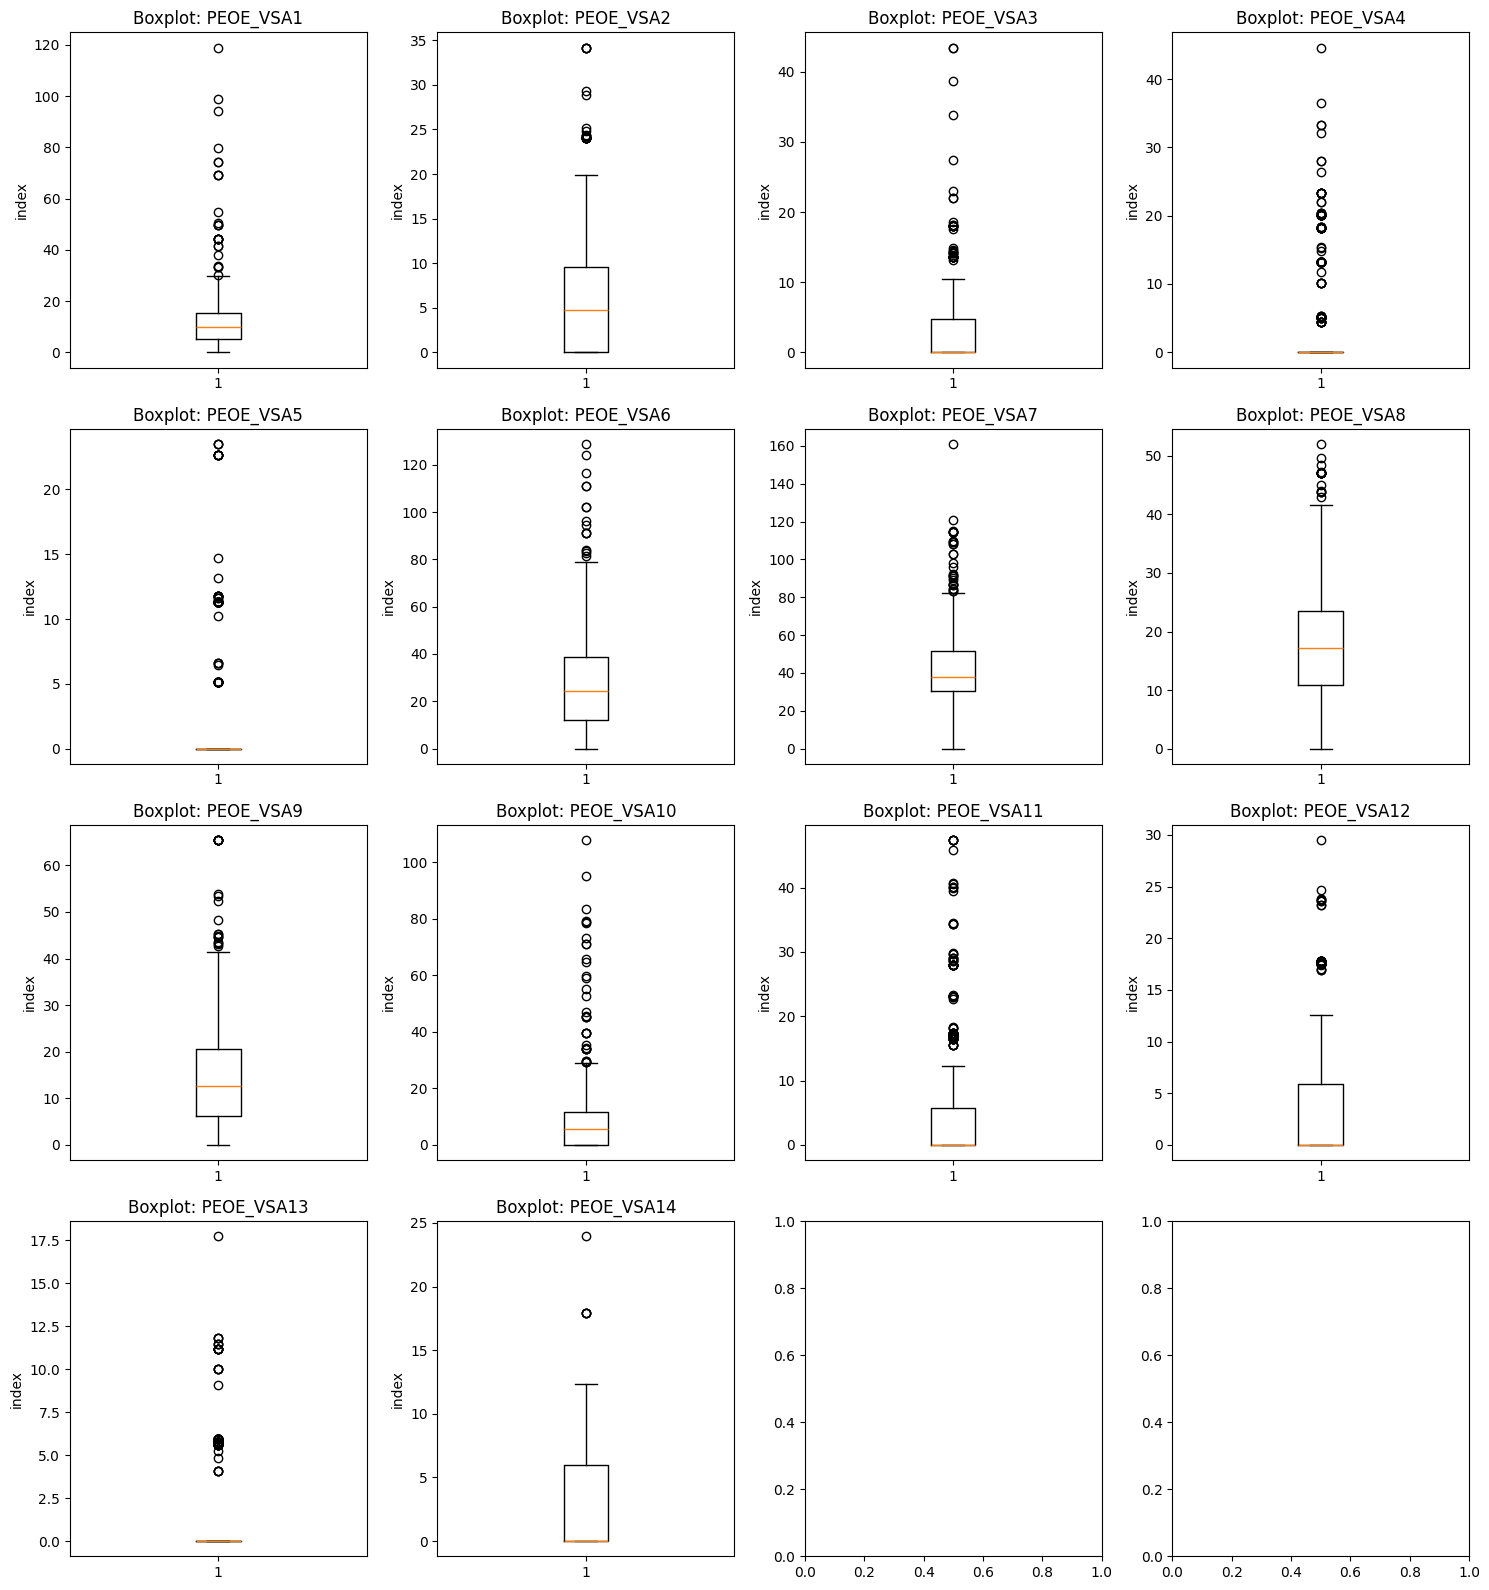

In [ ]:
# Box-plot'ы дескрипторов PEOE_VSA
fig, axes = plt.subplots(4, 4, figsize=(15, 16))
for i in range(3):
    for j, col in enumerate(features_1[4*i:4*(i+1)]):
        axes[i][j].boxplot(df_train[col])
        axes[i][j].set_title(f'Boxplot: {col}')
        axes[i][j].set_ylabel('index')
for k, col in enumerate(features_1[-2:]):
    axes[3][k].boxplot(df_train[col])
    axes[3][k].set_title(f'Boxplot: {col}')
    axes[3][k].set_ylabel('index')
plt.tight_layout()
plt.show()

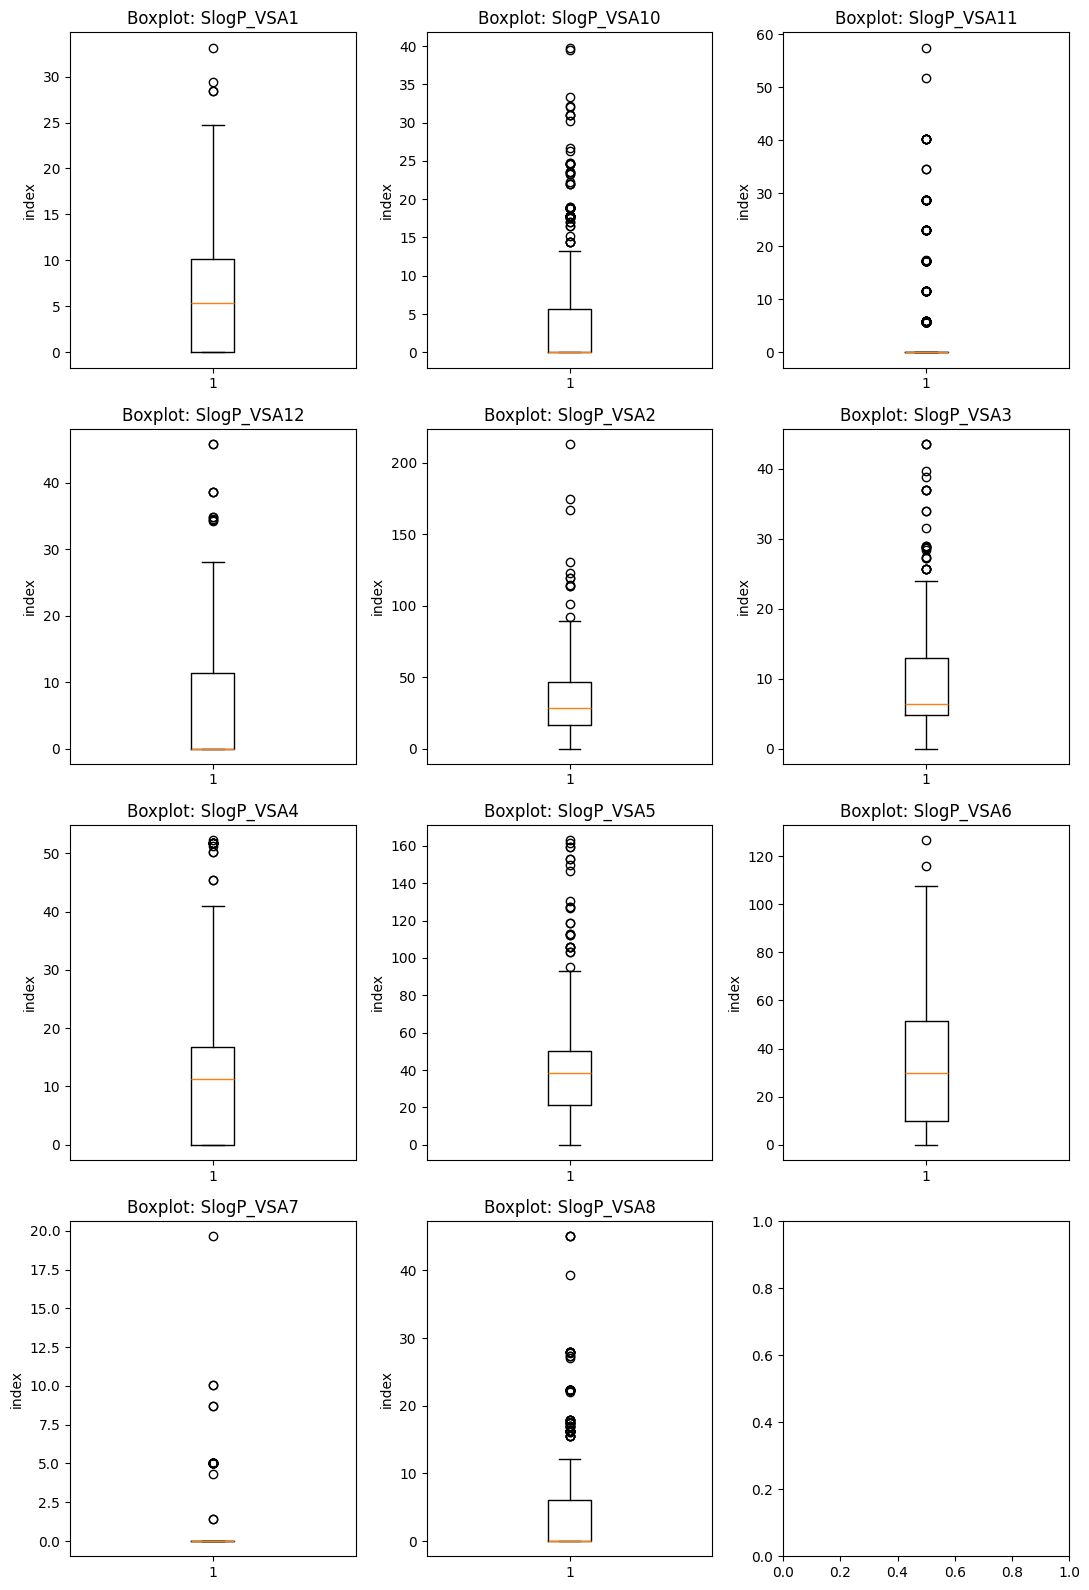

In [ ]:
# Box-plot'ы дескрипторов SlogP
fig, axes = plt.subplots(4, 3, figsize=(11, 16))
for i in range(3):
    for j, col in enumerate(subfamilies['SlogP_VSA'][3*i:3*(i+1)]):
        axes[i][j].boxplot(df_train[col])
        axes[i][j].set_title(f'Boxplot: {col}')
        axes[i][j].set_ylabel('index')
for k, col in enumerate(subfamilies['SlogP_VSA'][-2:]):
    axes[3][k].boxplot(df_train[col])
    axes[3][k].set_title(f'Boxplot: {col}')
    axes[3][k].set_ylabel('index')
plt.tight_layout()
plt.show()

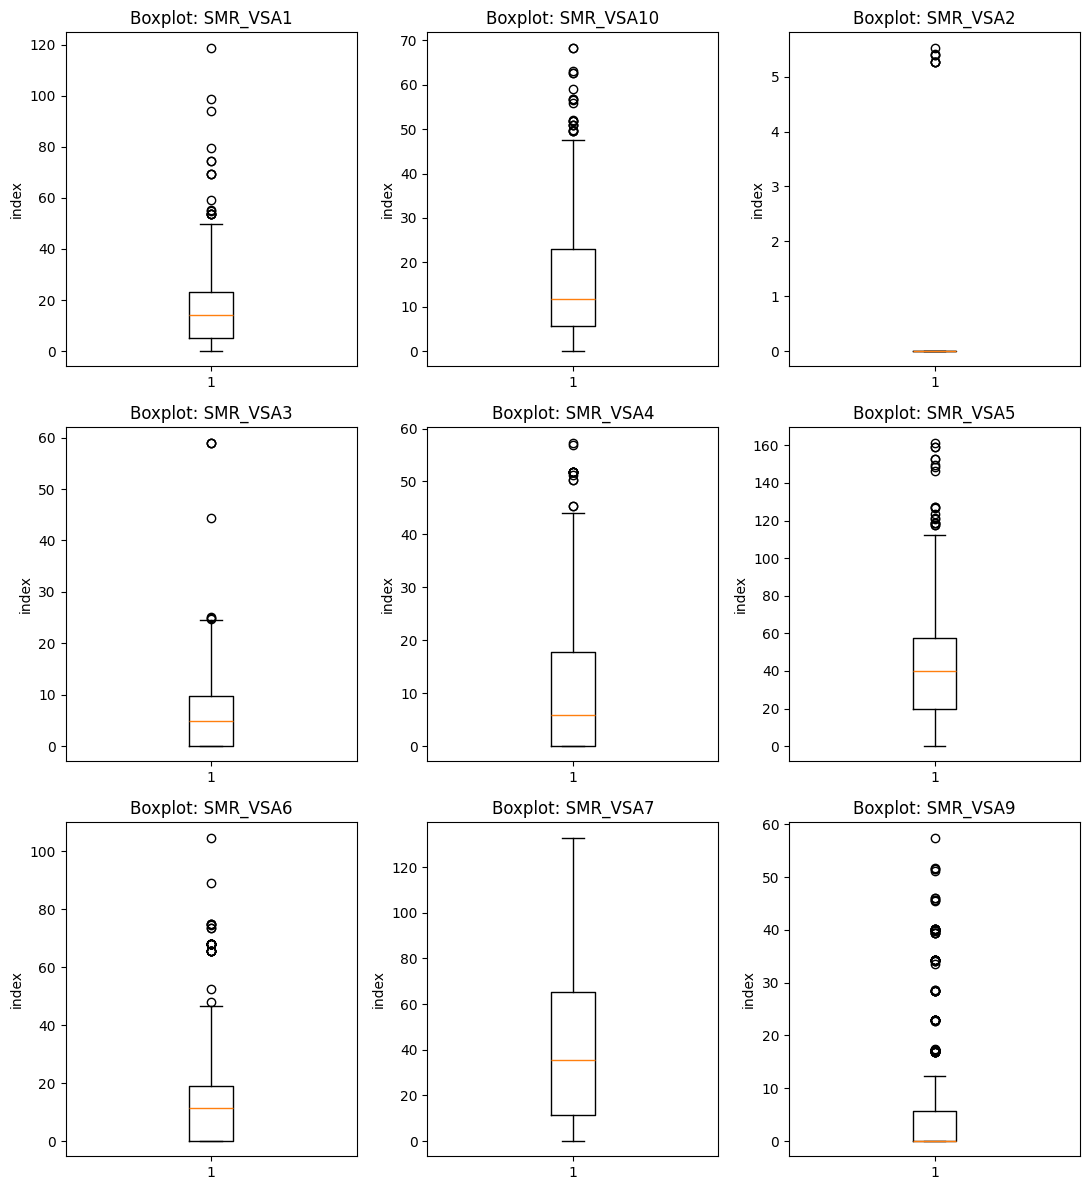

In [ ]:
# Box-plot'ы дескрипторов SMR
fig, axes = plt.subplots(3, 3, figsize=(11, 12))
for i in range(3):
    for j, col in enumerate(subfamilies['SMR_VSA'][3*i:3*(i+1)]):
        axes[i][j].boxplot(df_train[col])
        axes[i][j].set_title(f'Boxplot: {col}')
        axes[i][j].set_ylabel('index')
plt.tight_layout()
plt.show()

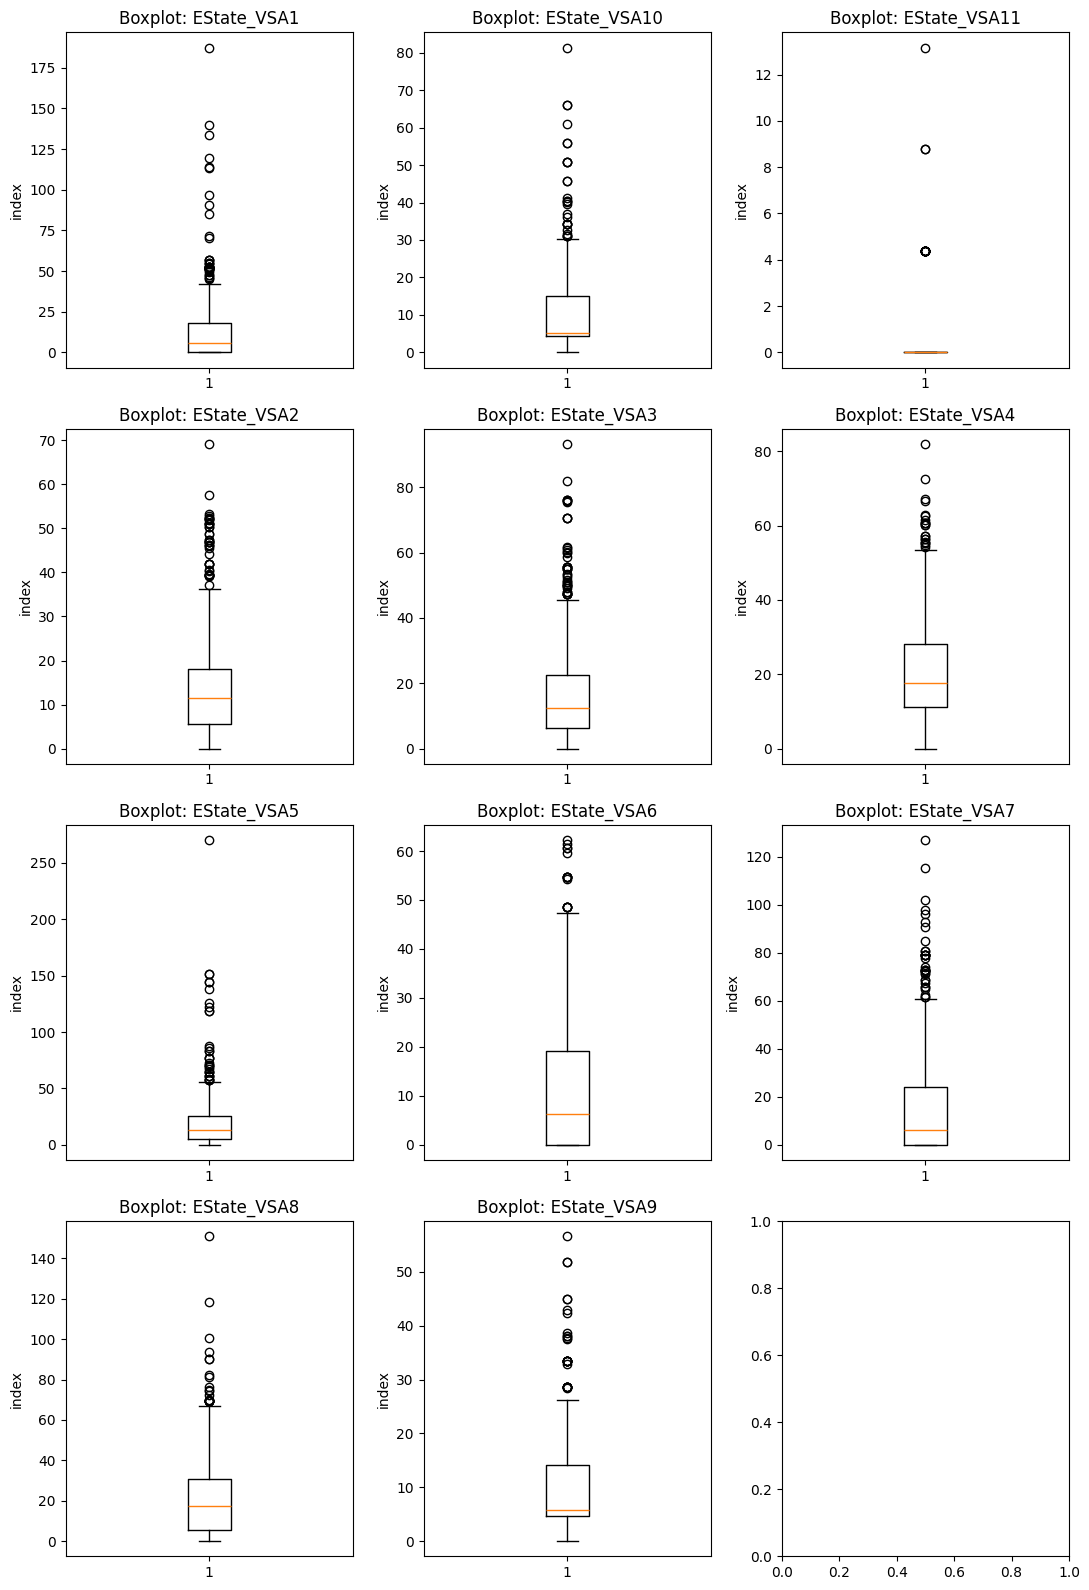

In [ ]:
# Box-plot'ы дескрипторов EState-VSA
fig, axes = plt.subplots(4, 3, figsize=(11, 16))
for i in range(3):
    for j, col in enumerate(subfamilies['EState_VSA'][3*i:3*(i+1)]):
        axes[i][j].boxplot(df_train[col])
        axes[i][j].set_title(f'Boxplot: {col}')
        axes[i][j].set_ylabel('index')
for k, col in enumerate(subfamilies['EState_VSA'][-2:]):
    axes[3][k].boxplot(df_train[col])
    axes[3][k].set_title(f'Boxplot: {col}')
    axes[3][k].set_ylabel('index')
plt.tight_layout()
plt.show()

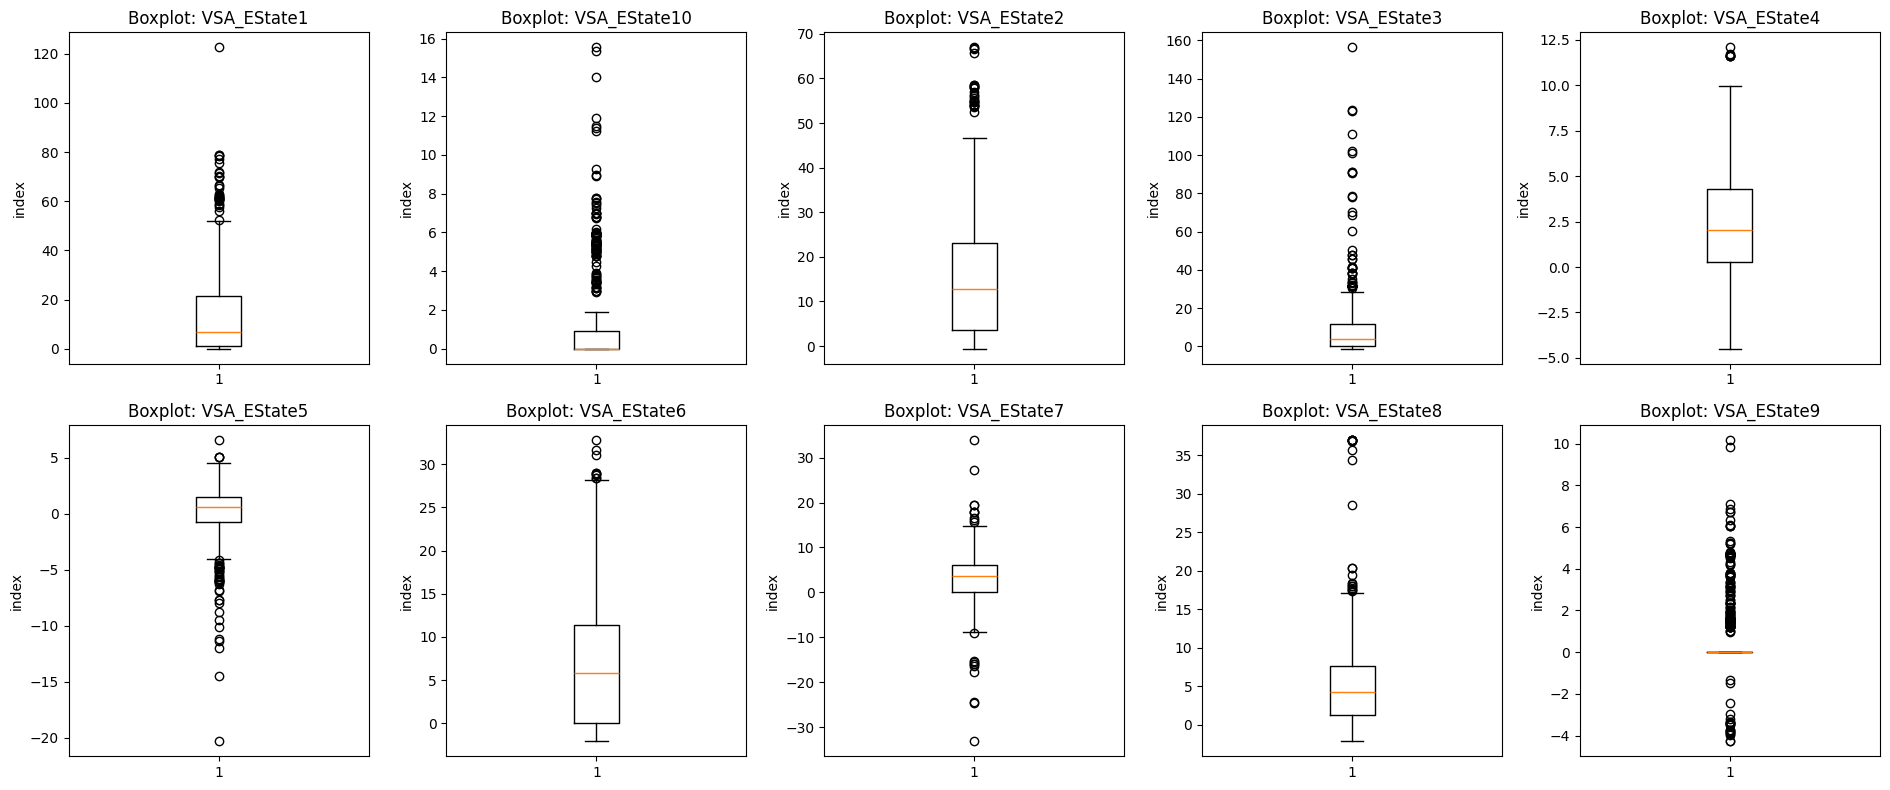

In [ ]:
# Box-plot'ы дескрипторов VSA-EState
fig, axes = plt.subplots(2, 5, figsize=(19, 8))
for i in range(2):
    for j, col in enumerate(subfamilies['VSA_EState'][5*i:5*(i+1)]):
        axes[i][j].boxplot(df_train[col])
        axes[i][j].set_title(f'Boxplot: {col}')
        axes[i][j].set_ylabel('index')
plt.tight_layout()
plt.show()

В группе признаков VSA наблюдаются выраженные выбросы и длинные правые хвосты распределений.

Это является ожидаемым поведением для химических дескрипторов, поскольку данные признаки описывают:
- вклад различных атомных групп в площадь поверхности молекулы;
- распределение электронной плотности;
- липофильность;
- молекулярную рефрактивность;
- топологические особенности структуры.

Экстремальные значения могут соответствовать:
- крупным молекулам;
- соединениям с высокой полярностью;
- редким функциональным группам;
- молекулам с необычным распределением зарядов.

По этой причине выбросы не рассматриваются как ошибки автоматически и массовое удаление строк не выполняется.

Для дальнейшего моделирования предпочтительно использовать:
- робастное масштабирование (`RobustScaler`);
- логарифмирование сильно скошенных признаков;
- модели, устойчивые к выбросам (CatBoost, LightGBM, XGBoost).

### Логарифмирование признаков

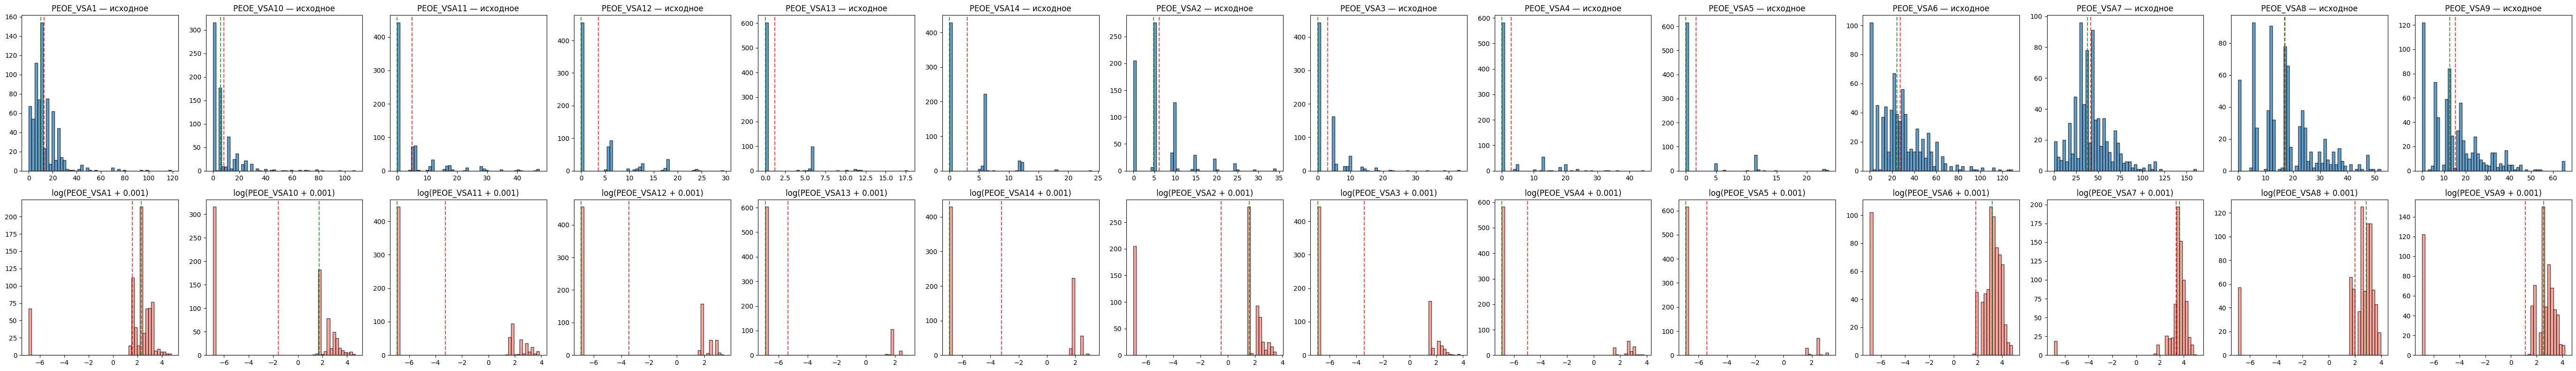


Статистика log-целей по PEOE-VSA:

  log(PEOE_VSA1): mean=1.582, std=2.758, median=2.303, min=-6.908, max=4.778

  log(PEOE_VSA10): mean=-1.603, std=4.645, median=1.741, min=-6.908, max=4.681

  log(PEOE_VSA11): mean=-3.264, std=4.519, median=-6.908, min=-6.908, max=3.859

  log(PEOE_VSA12): mean=-3.475, std=4.396, median=-6.908, min=-6.908, max=3.385

  log(PEOE_VSA13): mean=-5.346, std=3.355, median=-6.908, min=-6.908, max=2.875

  log(PEOE_VSA14): mean=-3.233, std=4.366, median=-6.908, min=-6.908, max=3.176

  log(PEOE_VSA2): mean=-0.487, std=4.023, median=1.568, min=-6.908, max=3.532

  log(PEOE_VSA3): mean=-3.415, std=4.323, median=-6.908, min=-6.908, max=3.772

  log(PEOE_VSA4): mean=-4.952, std=3.839, median=-6.908, min=-6.908, max=3.798

  log(PEOE_VSA5): mean=-5.432, std=3.378, median=-6.908, min=-6.908, max=3.158

  log(PEOE_VSA6): mean=1.850, std=3.571, median=3.189, min=-6.908, max=4.859

  log(PEOE_VSA7): mean=3.363, std=1.754, median=3.638, min=-6.908, max=5.082

  log(P

In [ ]:
fig, axes = plt.subplots(2, 14, figsize=(55, 8))

for i, col in enumerate(features_1):
    # Исходные
    axes[0, i].hist(df_train[col], bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} — исходное')
    axes[0, i].axvline(df_train[col].mean(), color='red', linestyle='--', alpha=0.7)
    axes[0, i].axvline(df_train[col].median(), color='green', linestyle='--', alpha=0.7)

    # Логарифмированные (добавляем маленькую константу, если есть нули)
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
        label = f'log({col} + {shift:.3f})'
    else:
        log_col = np.log(df_train[col])
        label = f'log({col})'

    axes[1, i].hist(log_col, bins=50, edgecolor='black', alpha=0.7, color='salmon')
    axes[1, i].set_title(label)
    axes[1, i].axvline(log_col.mean(), color='red', linestyle='--', alpha=0.7)
    axes[1, i].axvline(log_col.median(), color='green', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Статистика логарифмированных
print("\nСтатистика log-целей по PEOE-VSA:")
for col in features_1:
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
    else:
        log_col = np.log(df_train[col])
    print(f"\n  log({col}): mean={log_col.mean():.3f}, std={log_col.std():.3f}, "
          f"median={log_col.median():.3f}, min={log_col.min():.3f}, max={log_col.max():.3f}")

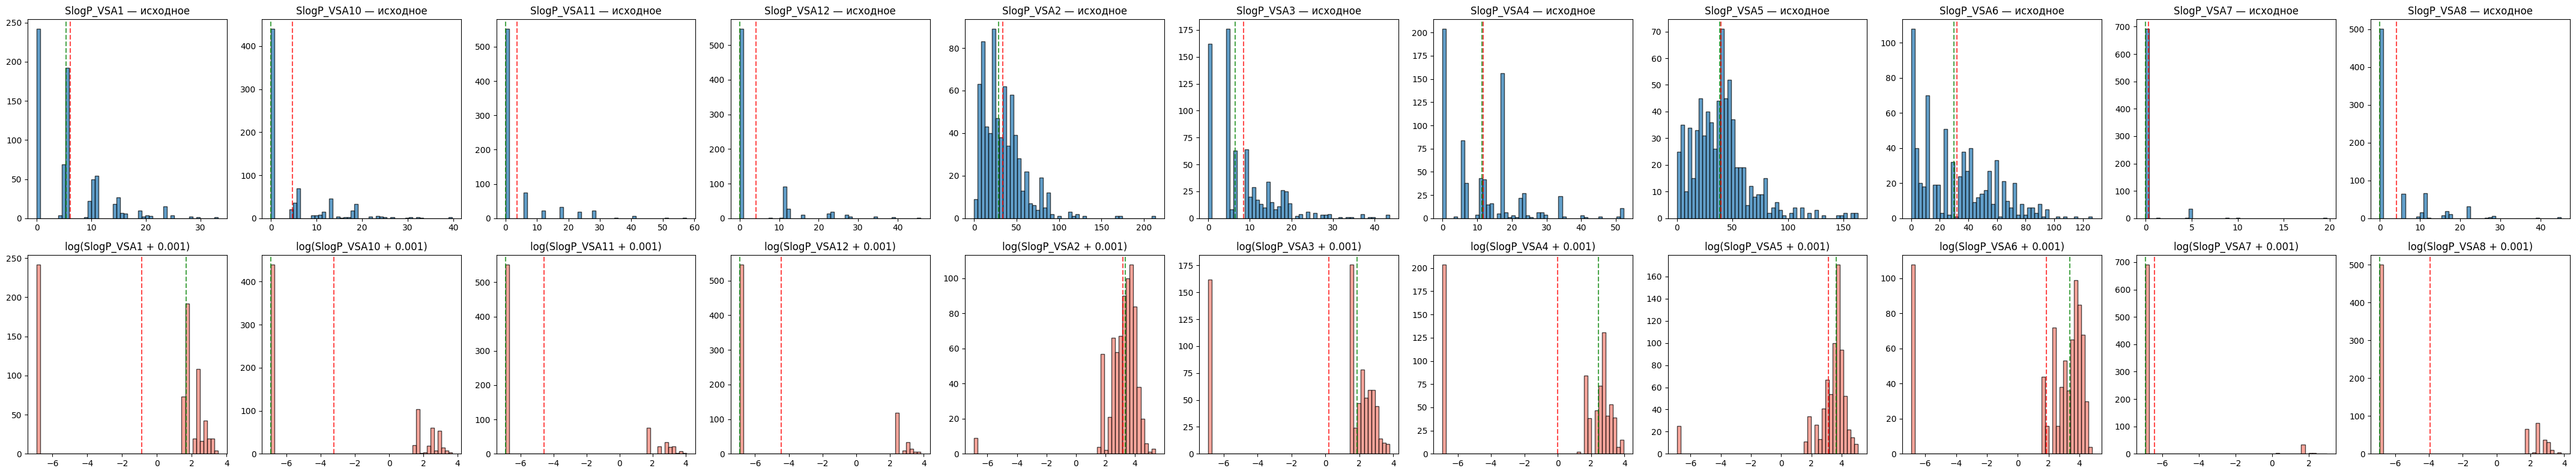


Статистика log-целей по SlogP_VSA:

  log(SlogP_VSA1): mean=-0.882, std=4.249, median=1.671, min=-6.908, max=3.501

  log(SlogP_VSA10): mean=-3.226, std=4.522, median=-6.908, min=-6.908, max=3.684

  log(SlogP_VSA11): mean=-4.577, std=4.076, median=-6.908, min=-6.908, max=4.052

  log(SlogP_VSA12): mean=-4.456, std=4.201, median=-6.908, min=-6.908, max=3.826

  log(SlogP_VSA2): mean=3.167, std=1.342, median=3.356, min=-6.908, max=5.362

  log(SlogP_VSA3): mean=0.205, std=3.822, median=1.860, min=-6.908, max=3.774

  log(SlogP_VSA4): mean=-0.018, std=4.304, median=2.428, min=-6.908, max=3.956

  log(SlogP_VSA5): mean=3.153, std=2.010, median=3.651, min=-6.908, max=5.094

  log(SlogP_VSA6): mean=1.847, std=3.716, median=3.396, min=-6.908, max=4.842

  log(SlogP_VSA7): mean=-6.419, std=1.989, median=-6.908, min=-6.908, max=2.978

  log(SlogP_VSA8): mean=-3.938, std=4.368, median=-6.908, min=-6.908, max=3.808


In [ ]:
fig, axes = plt.subplots(2, 11, figsize=(43, 8))

for i, col in enumerate(subfamilies['SlogP_VSA']):
    # Исходные
    axes[0, i].hist(df_train[col], bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} — исходное')
    axes[0, i].axvline(df_train[col].mean(), color='red', linestyle='--', alpha=0.7)
    axes[0, i].axvline(df_train[col].median(), color='green', linestyle='--', alpha=0.7)

    # Логарифмированные (добавляем маленькую константу, если есть нули)
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
        label = f'log({col} + {shift:.3f})'
    else:
        log_col = np.log(df_train[col])
        label = f'log({col})'

    axes[1, i].hist(log_col, bins=50, edgecolor='black', alpha=0.7, color='salmon')
    axes[1, i].set_title(label)
    axes[1, i].axvline(log_col.mean(), color='red', linestyle='--', alpha=0.7)
    axes[1, i].axvline(log_col.median(), color='green', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Статистика логарифмированных
print("\nСтатистика log-целей по SlogP_VSA:")
for col in subfamilies['SlogP_VSA']:
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
    else:
        log_col = np.log(df_train[col])
    print(f"\n  log({col}): mean={log_col.mean():.3f}, std={log_col.std():.3f}, "
          f"median={log_col.median():.3f}, min={log_col.min():.3f}, max={log_col.max():.3f}")

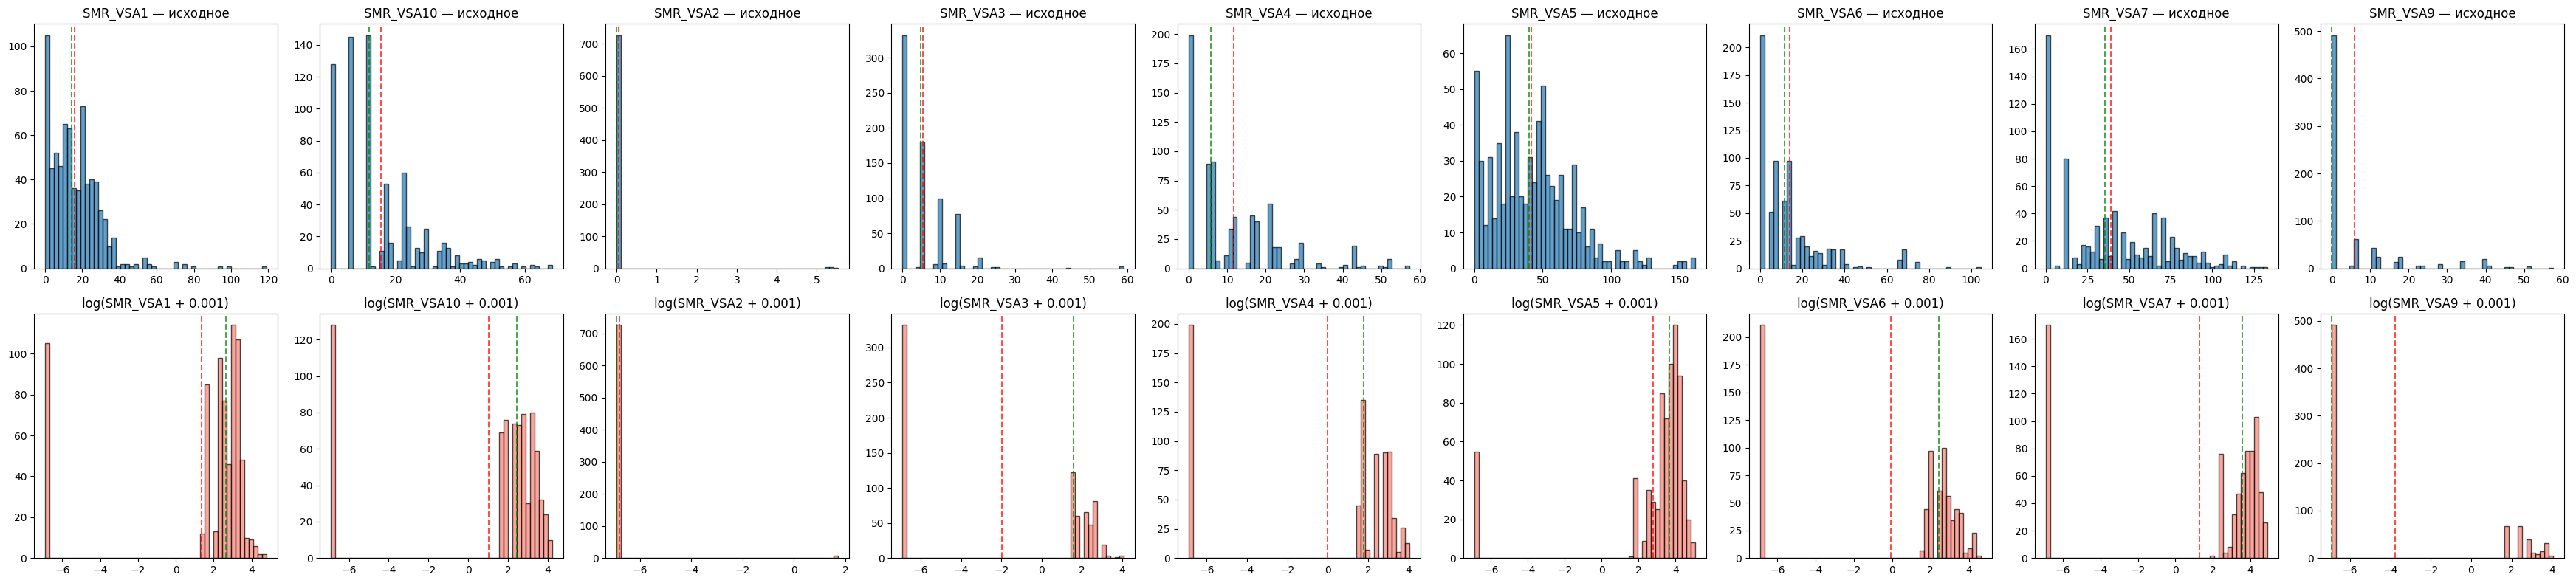


Статистика log-целей по SMR-VSA:

  log(SMR_VSA1): mean=1.341, std=3.429, median=2.658, min=-6.908, max=4.778

  log(SMR_VSA10): mean=1.031, std=3.703, median=2.464, min=-6.908, max=4.226

  log(SMR_VSA2): mean=-6.814, std=0.892, median=-6.908, min=-6.908, max=1.711

  log(SMR_VSA3): mean=-1.958, std=4.518, median=1.589, min=-6.908, max=4.079

  log(SMR_VSA4): mean=-0.020, std=4.244, median=1.778, min=-6.908, max=4.049

  log(SMR_VSA5): mean=2.807, std=2.853, median=3.690, min=-6.908, max=5.085

  log(SMR_VSA6): mean=-0.066, std=4.391, median=2.438, min=-6.908, max=4.651

  log(SMR_VSA7): mean=1.269, std=4.531, median=3.570, min=-6.908, max=4.890

  log(SMR_VSA9): mean=-3.749, std=4.512, median=-6.908, min=-6.908, max=4.052


In [ ]:
fig, axes = plt.subplots(2, 9, figsize=(35, 8))

for i, col in enumerate(subfamilies['SMR_VSA']):
    # Исходные
    axes[0, i].hist(df_train[col], bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} — исходное')
    axes[0, i].axvline(df_train[col].mean(), color='red', linestyle='--', alpha=0.7)
    axes[0, i].axvline(df_train[col].median(), color='green', linestyle='--', alpha=0.7)

    # Логарифмированные (добавляем маленькую константу, если есть нули)
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
        label = f'log({col} + {shift:.3f})'
    else:
        log_col = np.log(df_train[col])
        label = f'log({col})'

    axes[1, i].hist(log_col, bins=50, edgecolor='black', alpha=0.7, color='salmon')
    axes[1, i].set_title(label)
    axes[1, i].axvline(log_col.mean(), color='red', linestyle='--', alpha=0.7)
    axes[1, i].axvline(log_col.median(), color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Статистика логарифмированных
print("\nСтатистика log-целей по SMR-VSA:")
for col in subfamilies['SMR_VSA']:
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
    else:
        log_col = np.log(df_train[col])
    print(f"\n  log({col}): mean={log_col.mean():.3f}, std={log_col.std():.3f}, "
          f"median={log_col.median():.3f}, min={log_col.min():.3f}, max={log_col.max():.3f}")

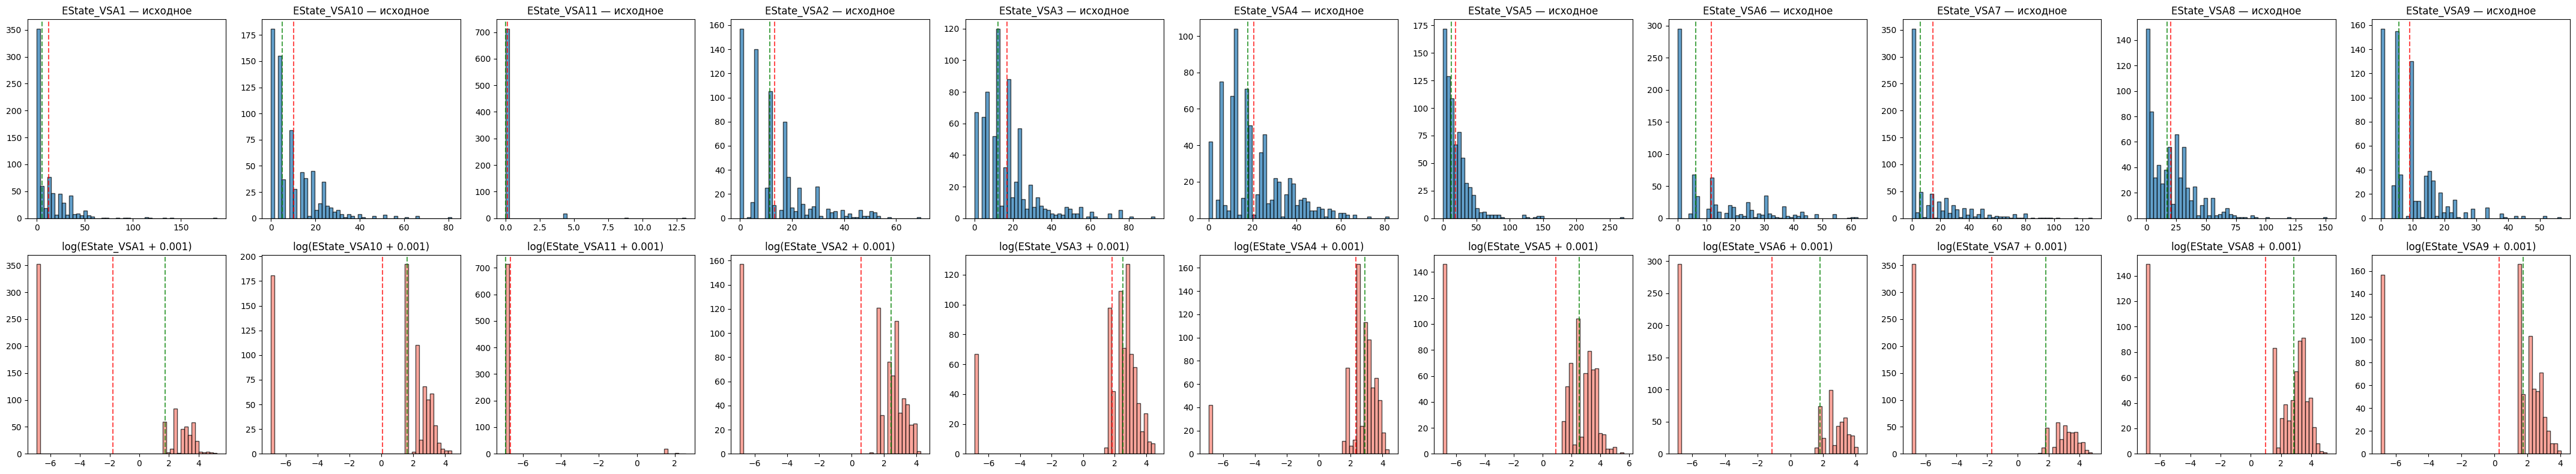


Статистика log-целей по EState-VSA:

  log(EState_VSA1): mean=-1.796, std=4.939, median=1.723, min=-6.908, max=5.233

  log(EState_VSA10): mean=0.083, std=4.046, median=1.631, min=-6.908, max=4.399

  log(EState_VSA11): mean=-6.664, std=1.420, median=-6.908, min=-6.908, max=2.578

  log(EState_VSA2): mean=0.588, std=3.955, median=2.436, min=-6.908, max=4.237

  log(EState_VSA3): mean=1.822, std=2.839, median=2.513, min=-6.908, max=4.535

  log(EState_VSA4): mean=2.327, std=2.359, median=2.877, min=-6.908, max=4.407

  log(EState_VSA5): mean=0.911, std=3.962, median=2.540, min=-6.908, max=5.600

  log(EState_VSA6): mean=-1.130, std=4.770, median=1.826, min=-6.908, max=4.131

  log(EState_VSA7): mean=-1.704, std=5.029, median=1.803, min=-6.908, max=4.843

  log(EState_VSA8): mean=0.968, std=4.038, median=2.860, min=-6.908, max=5.017

  log(EState_VSA9): mean=0.295, std=3.798, median=1.747, min=-6.908, max=4.036


In [ ]:
fig, axes = plt.subplots(2, 11, figsize=(43, 8))

for i, col in enumerate(subfamilies['EState_VSA']):
    # Исходные
    axes[0, i].hist(df_train[col], bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} — исходное')
    axes[0, i].axvline(df_train[col].mean(), color='red', linestyle='--', alpha=0.7)
    axes[0, i].axvline(df_train[col].median(), color='green', linestyle='--', alpha=0.7)

    # Логарифмированные (добавляем маленькую константу, если есть нули)
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
        label = f'log({col} + {shift:.3f})'
    else:
        log_col = np.log(df_train[col])
        label = f'log({col})'

    axes[1, i].hist(log_col, bins=50, edgecolor='black', alpha=0.7, color='salmon')
    axes[1, i].set_title(label)
    axes[1, i].axvline(log_col.mean(), color='red', linestyle='--', alpha=0.7)
    axes[1, i].axvline(log_col.median(), color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Статистика логарифмированных
print("\nСтатистика log-целей по EState-VSA:")
for col in subfamilies['EState_VSA']:
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
    else:
        log_col = np.log(df_train[col])
    print(f"\n  log({col}): mean={log_col.mean():.3f}, std={log_col.std():.3f}, "
          f"median={log_col.median():.3f}, min={log_col.min():.3f}, max={log_col.max():.3f}")

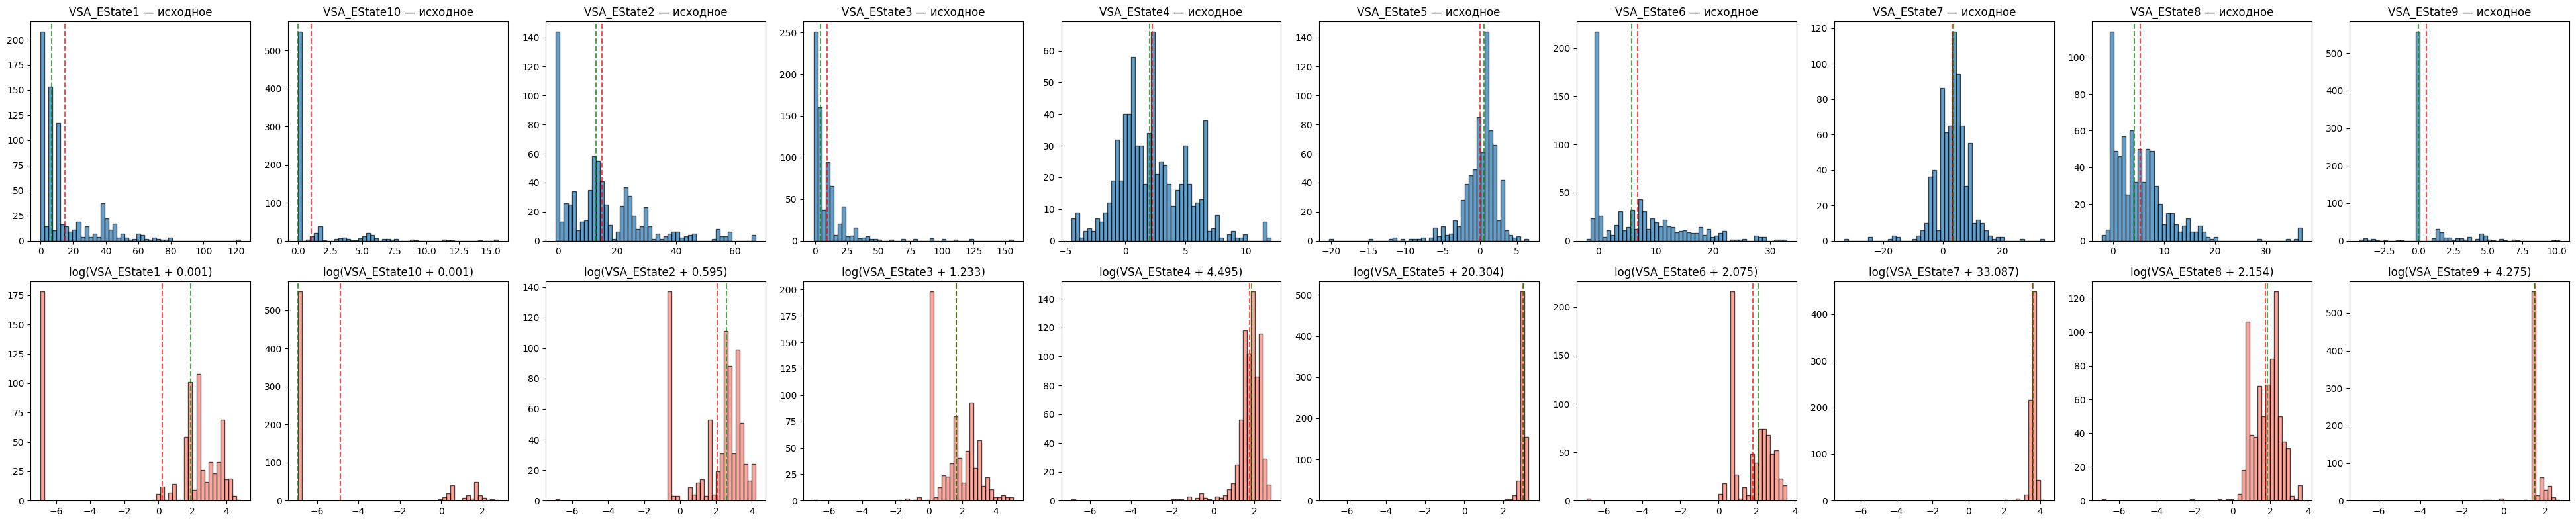


Статистика log-целей по VSA-EState:

  log(VSA_EState1): mean=0.248, std=4.141, median=1.895, min=-6.908, max=4.809

  log(VSA_EState10): mean=-4.870, std=3.530, median=-6.908, min=-6.908, max=2.744

  log(VSA_EState2): mean=2.068, std=1.483, median=2.602, min=-6.908, max=4.213

  log(VSA_EState3): mean=1.648, std=1.238, median=1.659, min=-6.908, max=5.060

  log(VSA_EState4): mean=1.770, std=0.667, median=1.876, min=-6.908, max=2.808

  log(VSA_EState5): mean=2.994, std=0.390, median=3.041, min=-6.908, max=3.292

  log(VSA_EState6): mean=1.785, std=1.033, median=2.061, min=-6.908, max=3.552

  log(VSA_EState7): mean=3.567, std=0.421, median=3.604, min=-6.908, max=4.205

  log(VSA_EState8): mean=1.762, std=0.795, median=1.852, min=-6.908, max=3.667

  log(VSA_EState9): mean=1.495, std=0.558, median=1.453, min=-6.908, max=2.671


In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(39, 8))

for i, col in enumerate(subfamilies['VSA_EState']):
    # Исходные
    axes[0, i].hist(df_train[col], bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} — исходное')
    axes[0, i].axvline(df_train[col].mean(), color='red', linestyle='--', alpha=0.7)
    axes[0, i].axvline(df_train[col].median(), color='green', linestyle='--', alpha=0.7)

    # Логарифмированные (добавляем маленькую константу, если есть нули)
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
        label = f'log({col} + {shift:.3f})'
    else:
        log_col = np.log(df_train[col])
        label = f'log({col})'

    axes[1, i].hist(log_col, bins=50, edgecolor='black', alpha=0.7, color='salmon')
    axes[1, i].set_title(label)
    axes[1, i].axvline(log_col.mean(), color='red', linestyle='--', alpha=0.7)
    axes[1, i].axvline(log_col.median(), color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Статистика логарифмированных
print("\nСтатистика log-целей по VSA-EState:")
for col in subfamilies['VSA_EState']:
    min_val = df_train[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 0.001
        log_col = np.log(df_train[col] + shift)
    else:
        log_col = np.log(df_train[col])
    print(f"\n  log({col}): mean={log_col.mean():.3f}, std={log_col.std():.3f}, "
          f"median={log_col.median():.3f}, min={log_col.min():.3f}, max={log_col.max():.3f}")

Для большинства VSA-дескрипторов наблюдается сильная положительная асимметрия и наличие тяжёлых хвостов распределений.

Это связано с тем, что:
- многие атомные фрагменты встречаются редко;
- значения площадей поверхности могут значительно различаться между малыми и крупными молекулами;
- часть признаков содержит большое количество малых значений и ограниченное число экстремально больших наблюдений.

Для снижения асимметрии и стабилизации масштаба признаков применяется логарифмическое преобразование `log1p`.

Использование `log1p` позволяет:
- уменьшить влияние экстремальных значений;
- сделать распределения более компактными;
- повысить устойчивость модели;
- улучшить качество дальнейшего масштабирования.

Преобразование особенно полезно для дескрипторов:
- `PEOE_VSA*`;
- `SlogP_VSA*`;
- `SMR_VSA*`.

### Проверка распределений

In [ ]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew as skew_func

# Готовим данные
log_features = {}
sqrt_features = {}
yj_features = {}

for col in (features_1, features_2):
    x = df_train[col].values.reshape(-1, 1)

    log_features[col] = np.log(df_train[col])
    sqrt_features[col] = np.sqrt(df_train[col])

    pt = PowerTransformer(method='yeo-johnson')
    yj_features[col] = pt.fit_transform(x).flatten()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


TypeError: unhashable type: 'list'

In [ ]:
from scipy.stats import skew as skew_func

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
titles = ['Исходное', 'log', 'sqrt', 'Yeo-Johnson']

for i, col in enumerate(targets):
    data_list = [
        train_clean[col],
        log_targets[col],
        sqrt_targets[col],
        yj_targets[col]
    ]

    for j, (data, title) in enumerate(zip(data_list, titles)):
        ax = axes[i, j]

        # Преобразуем в numpy для единообразия
        if hasattr(data, 'values'):
            vals = data.values
        else:
            vals = np.array(data)

        ax.hist(vals, bins=40, density=True, alpha=0.6, edgecolor='black')

        mu, sigma = vals.mean(), vals.std()
        x_curve = np.linspace(vals.min(), vals.max(), 100)
        ax.plot(x_curve, stats.norm.pdf(x_curve, mu, sigma), 'r-', lw=2, alpha=0.7)

        skew_val = skew_func(vals)
        ax.set_title(f'{title}\nskew = {skew_val:.2f}', fontsize=9)
        ax.tick_params(labelsize=7)

plt.suptitle('Сравнение трансформаций переменных', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 95)
print(f"{'Цель':<15} {'Трансформация':<15} {'Skewness':<12} {'Shapiro p-val':<15} {'Примечание'}")
print("=" * 95)

for col in targets:
    transformations = {
        'Исходное': train_clean[col].values,
        'log': log_targets[col].values,
        'sqrt': sqrt_targets[col].values,
        'Yeo-Johnson': yj_targets[col] if isinstance(yj_targets[col], np.ndarray) else yj_targets[col]
    }

    best_name = ''
    best_skew = float('inf')

    for name, data in transformations.items():
        vals = np.array(data).flatten()
        skew_val = skew_func(vals)

        # Случайная подвыборка для теста Шапиро
        n_sample = min(500, len(vals))
        rng = np.random.RandomState(42)
        sample_for_test = rng.choice(vals, size=n_sample, replace=False)
        _, shapiro_p = stats.shapiro(sample_for_test)

        note = ''
        if shapiro_p > 0.05:
            note = '✓ норм. распр.'

        if abs(skew_val) < abs(best_skew):
            best_skew = skew_val
            best_name = name

        print(f"{col:<15} {name:<15} {skew_val:<12.4f} {shapiro_p:<15.4f} {note}")

    print(f"  → Лучшая для {col}: {best_name} (|skew| = {abs(best_skew):.4f})")
    print("-" * 95)

Распределения VSA-дескрипторов в большинстве случаев являются асимметричными и содержат большое количество нулевых либо малых значений.

Наиболее выраженная асимметрия наблюдается у:
- `PEOE_VSA*`;
- `SMR_VSA*`;
- отдельных `VSA_EState*` признаков.

Подобная структура распределений типична для химических данных, поскольку:
- многие атомные окружения встречаются редко;
- отдельные функциональные группы присутствуют лишь у небольшой части молекул;
- вклад различных атомов в поверхность молекулы распределён неравномерно.

Признаки не приводятся к нормальному распределению искусственно, поскольку для бустинговых моделей это не является обязательным условием.

Для части непрерывных признаков может быть полезно применение `RobustScaler`.

Это позволит уменьшить влияние длинных хвостов распределения.

In [ ]:
# Итоговая рекомендация и сохранение лучших трансформаций
from scipy.stats import skew as skew_func

print("РЕКОМЕНДАЦИЯ ПО ТРАНСФОРМАЦИЯМ:\n")

best_transformations = {}
best_names = {}

for col in targets:
    skew_orig = skew_func(train_clean[col].values)

    candidates = {
        'log': skew_func(log_targets[col].values.flatten()),
        'sqrt': skew_func(sqrt_targets[col].values.flatten()),
        'Yeo-Johnson': skew_func(yj_targets[col].flatten() if isinstance(yj_targets[col], np.ndarray) else np.array(yj_targets[col]).flatten())
    }

    # Находим лучшую (минимальный |skew|)
    best_name = min(candidates, key=lambda k: abs(candidates[k]))
    best_skew = candidates[best_name]
    improvement = (abs(skew_orig) - abs(best_skew)) / abs(skew_orig) * 100

    print(f"  {col}:")
    print(f"    Исходный skew = {skew_orig:.2f}")
    print(f"    Лучшая — {best_name} (skew = {best_skew:.2f}, улучшение на {improvement:.0f}%)")

    best_names[col] = best_name

    if best_name == 'log':
        best_transformations[col] = log_targets[col]
    elif best_name == 'sqrt':
        best_transformations[col] = sqrt_targets[col]
    else:
        best_transformations[col] = yj_targets[col]

print(f"\nВыбранные трансформации: {best_names}")
print("best_transformations — словарь с трансформированными значениями")

### Корреляция признаков

In [ ]:
# 1. Доля нулей в PEOE_VSA бинах
peoe_cols = [f for f in group_peoe_vsa]
print(f"Группа: PEOE_VSA ({len(peoe_cols)} признаков)")
if peoe_cols:
    zero_frac = (df_train[peoe_cols] == 0).mean().sort_values(ascending=False)
    print("\nДоля нулей в PEOE_VSA бинах:")
    for col, frac in zero_frac.items():
        flag = ' ← УДАЛИТЬ (>95%)' if frac > 0.95 else ''
        print(f"  {col}: {frac:.3f} ({frac*100:.1f}%){flag}")

Группа: PEOE_VSA (14 признаков)

Доля нулей в PEOE_VSA бинах:
  PEOE_VSA5: 0.839 (83.9%)
  PEOE_VSA13: 0.822 (82.2%)
  PEOE_VSA4: 0.793 (79.3%)
  PEOE_VSA12: 0.620 (62.0%)
  PEOE_VSA11: 0.604 (60.4%)
  PEOE_VSA3: 0.604 (60.4%)
  PEOE_VSA14: 0.584 (58.4%)
  PEOE_VSA10: 0.431 (43.1%)
  PEOE_VSA2: 0.279 (27.9%)
  PEOE_VSA9: 0.166 (16.6%)
  PEOE_VSA6: 0.139 (13.9%)
  PEOE_VSA1: 0.091 (9.1%)
  PEOE_VSA8: 0.078 (7.8%)
  PEOE_VSA7: 0.026 (2.6%)


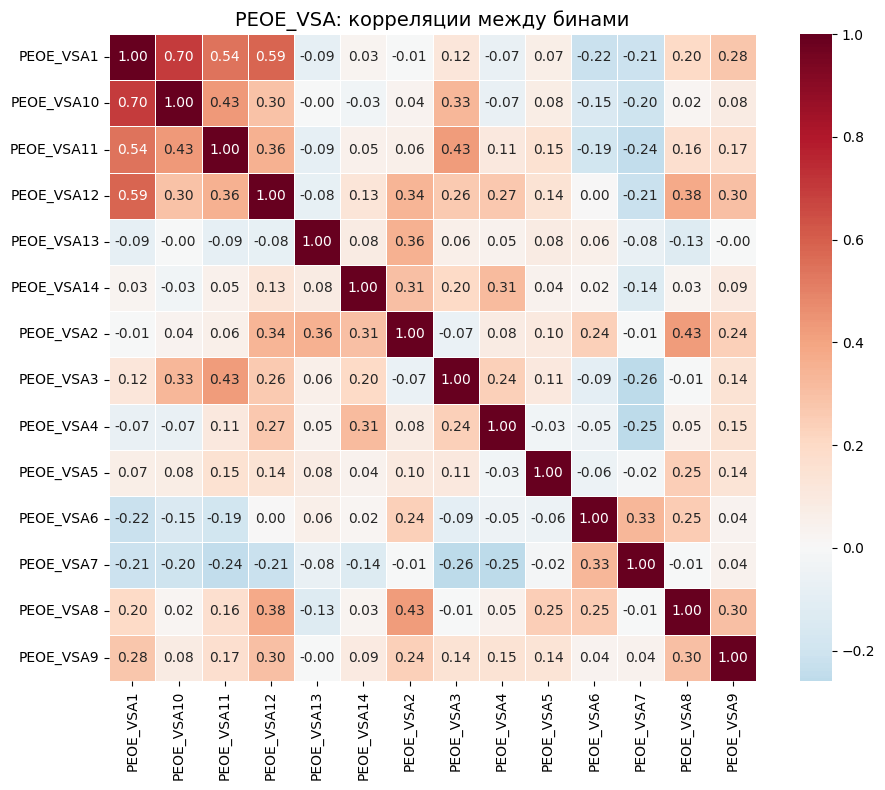

In [ ]:
# 2. Хитмэп PEOE_VSA
if len(peoe_cols) > 1:
    peoe_corr = df_train[peoe_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(peoe_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5)
    plt.title('PEOE_VSA: корреляции между бинами', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
for name, cols in subfamilies.items():
    if len(cols) > 1:
        print(f"\n{name} ({len(cols)} бинов):")
        # Доля нулей
        zero_frac = (df_train[cols] == 0).mean()
        for col, frac in zero_frac.sort_values(ascending=False).items():
            if frac > 0.5:
                flag = f' ← {frac*100:.0f}% нулей'
                print(f"  {col}: {flag}")

Группа: SURFACE_VSA (41 признаков)

SlogP_VSA (11 бинов):
  SlogP_VSA7:  ← 94% нулей
  SlogP_VSA11:  ← 75% нулей
  SlogP_VSA12:  ← 75% нулей
  SlogP_VSA8:  ← 68% нулей
  SlogP_VSA10:  ← 60% нулей

SMR_VSA (9 бинов):
  SMR_VSA2:  ← 99% нулей
  SMR_VSA9:  ← 67% нулей

EState_VSA (11 бинов):
  EState_VSA11:  ← 97% нулей

VSA_EState (10 бинов):
  VSA_EState9:  ← 76% нулей
  VSA_EState10:  ← 75% нулей


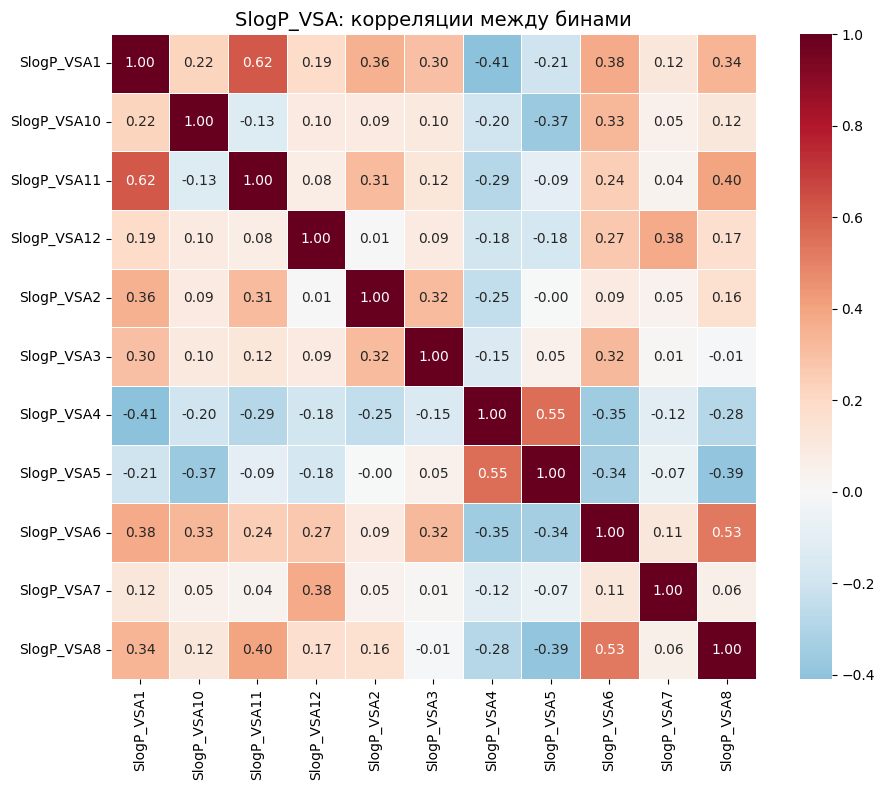

In [ ]:
# Корреляция для подсемейства SlogP
slogp_cols = subfamilies['SlogP_VSA']
if len(slogp_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_train[slogp_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5)
    plt.title('SlogP_VSA: корреляции между бинами', fontsize=14)
    plt.tight_layout()
    plt.show()

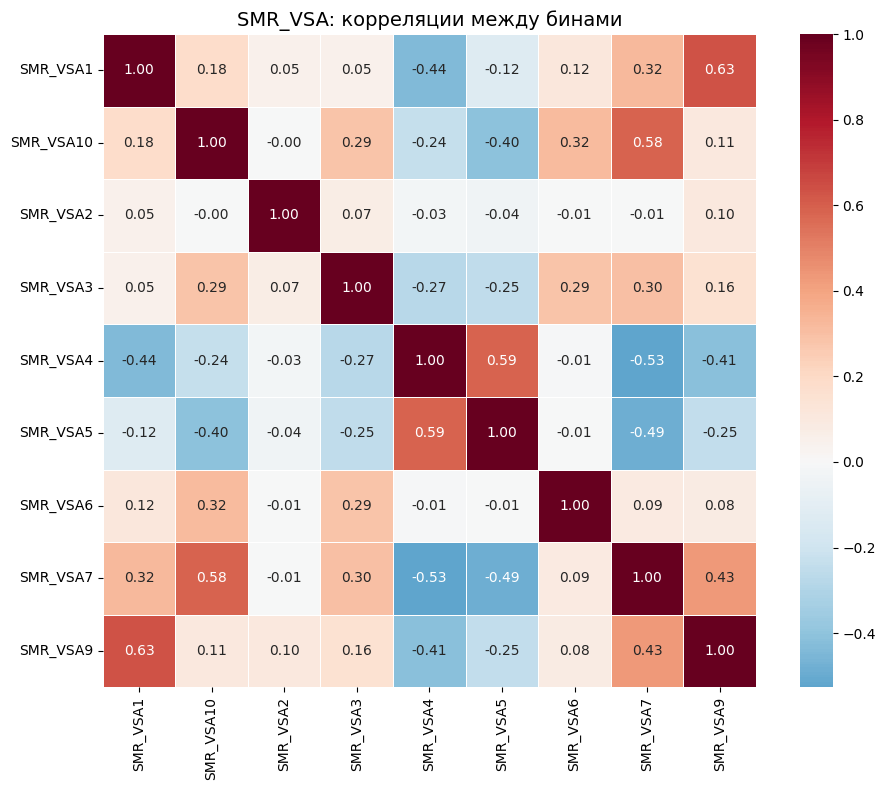

In [ ]:
# Корреляция для подсемейства SMR
smr_cols = subfamilies['SMR_VSA']
if len(smr_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_train[smr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5)
    plt.title('SMR_VSA: корреляции между бинами', fontsize=14)
    plt.tight_layout()
    plt.show()

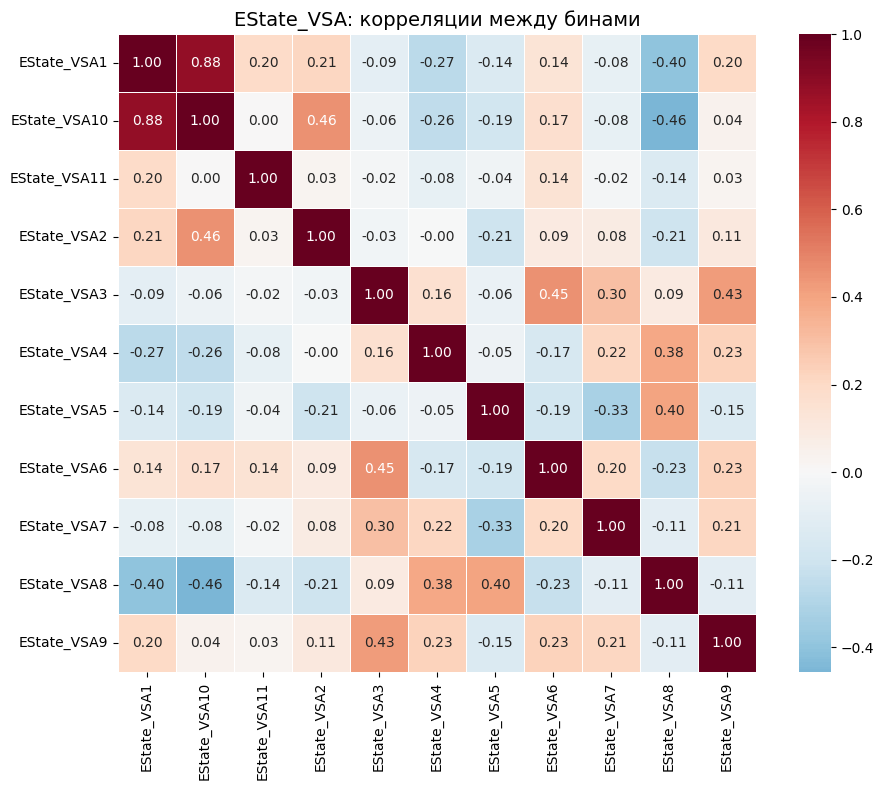

In [ ]:
# Корреляция для подсемейства EState_VSA
estate_vsa_cols = subfamilies['EState_VSA']
if len(estate_vsa_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_train[estate_vsa_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5)
    plt.title('EState_VSA: корреляции между бинами', fontsize=14)
    plt.tight_layout()
    plt.show()

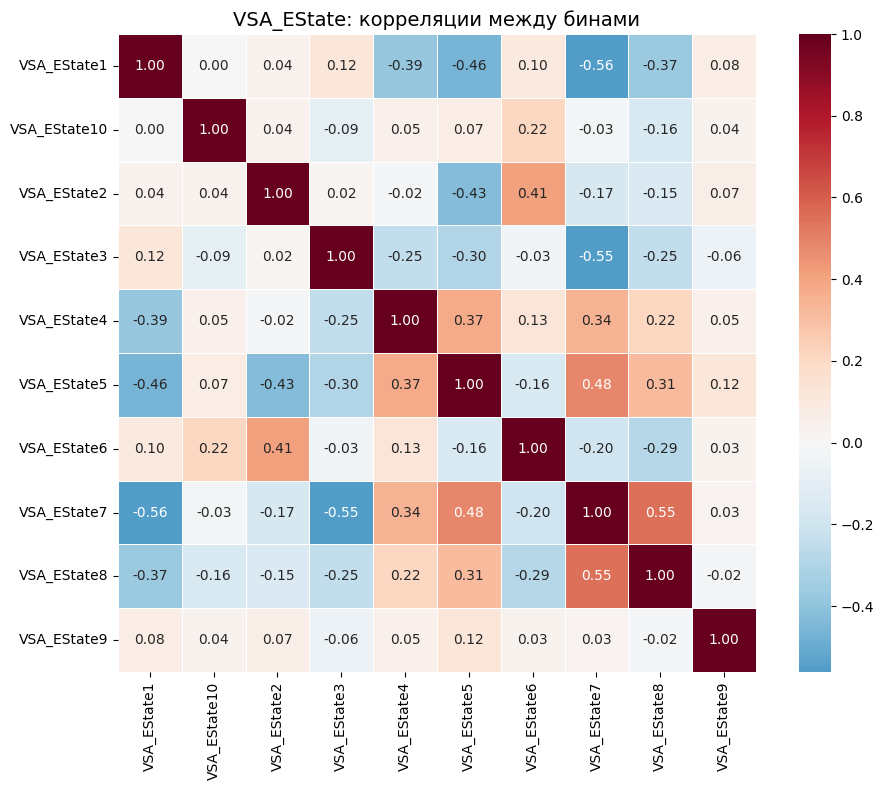

In [ ]:
# Корреляция для подсемейства VSA_EState
vsa_estate_cols = subfamilies['VSA_EState']
if len(vsa_estate_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_train[vsa_estate_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5)
    plt.title('VSA_EState: корреляции между бинами', fontsize=14)
    plt.tight_layout()
    plt.show()

Корреляционный анализ показал наличие выраженной мультиколлинеарности внутри групп VSA-дескрипторов.

Особенно сильная корреляция наблюдается:
- между соседними признаками одного семейства;
- между признаками, описывающими схожие физико-химические свойства молекулы.

Это объясняется тем, что VSA-дескрипторы формируются на основе близких характеристик:
- площади поверхности;
- электронной структуры;
- липофильности;
- молекулярной рефрактивности.

Для уменьшения избыточности признакового пространства рекомендуется:
- удалить признаки с корреляцией выше 0.95;
- оставить наиболее интерпретируемые признаки внутри каждой группы.

При этом умеренная корреляция между признаками считается допустимой, так как химические свойства молекул часто определяются совместным действием нескольких дескрипторов.

### Корреляция с целевыми переменными

VSA-дескрипторы демонстрируют заметную связь с целевыми переменными, особенно с показателями противовирусной активности и токсичности.

Наиболее информативными оказываются признаки, отражающие:
- распределение электронной плотности (`PEOE_VSA*`);
- липофильность (`SlogP_VSA*`);
- топологические характеристики поверхности (`VSA_EState*`).

Это согласуется с химической природой задачи, поскольку:
- проникновение вещества через мембраны зависит от липофильности;
- распределение зарядов влияет на взаимодействие молекулы с белковыми мишенями;
- площадь поверхности связана с растворимостью и биодоступностью соединений.

Для переменной `SI` линейные корреляции выражены слабее, что объясняется её составной природой:
SI одновременно зависит как от эффективности соединения, так и от его токсичности.

Признаки с низкой линейной корреляцией не удаляются, поскольку бустинговые модели способны извлекать нелинейные зависимости между дескрипторами.

### Итог по VSA-признакам

Признаки группы VSA содержат значимую химическую информацию и сохраняются для дальнейшего моделирования.

На текущем этапе рекомендуется:
- не удалять выбросы массово;
- применить робастное масштабирование;
- сохранить признаки даже при слабой линейной корреляции с целевыми переменными.

Данные дескрипторы потенциально являются важными предикторами противовирусной активности и токсичности соединений.